In [2]:
setwd("/home/mjehangir/telomere-sv-analysis/data/")


In [3]:
# Load necessary libraries
#library(openxlsx)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)
library(tibble)
#library(ggridges)
library(tidyverse)
  library(readr)
  library(stringr)
  library(GenomicRanges)
  library(purrr)


Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements a

In [4]:
ecdna <- read.delim("all_samples_summary.tsv", sep = "\t", header = TRUE)

head(ecdna)
str(ecdna)



,sample,circ_id,chr_origin,size.MB.,label,topology_idx,topology_name,estimated_proportions
,<chr>,<int>,<chr>,<dbl>,<chr>,<int>,<chr>,<int>
1,2436A,0,chr1,0.015960,,0,simple_circle,95
2,2436A,1,chr1,0.121904,ecDNA,1,simple_sv,108
3,2436A,2,chr2,0.013592,,0,simple_circle,89
4,2436A,3,chr3,0.004469,,0,simple_circle,1678
5,2436A,26,"chr15,chr18",0.004089,,4,multi_region_inter_chr,2627
6,2436A,5,"chr15,chr18",0.006083,,4,multi_region_inter_chr,1425


'data.frame':	290 obs. of  8 variables:
 $ sample               : chr  "2436A" "2436A" "2436A" "2436A" ...
 $ circ_id              : int  0 1 2 3 26 5 7 10 11 14 ...
 $ chr_origin           : chr  "chr1" "chr1" "chr2" "chr3" ...
 $ size.MB.             : num  0.01596 0.1219 0.01359 0.00447 0.00409 ...
 $ label                : chr  "" "ecDNA" "" "" ...
 $ topology_idx         : int  0 1 0 0 4 4 3 0 0 3 ...
 $ topology_name        : chr  "simple_circle" "simple_sv" "simple_circle" "simple_circle" ...
 $ estimated_proportions: int  95 108 89 1678 2627 1425 31 660 82 44 ...


In [5]:
ecbed <- read.delim("all_samples_reconstruct.ecDNA.filtered.bed",
                    header = TRUE, sep = "\t")


In [6]:
colnames(ecbed)[9] <- "sample"
colnames(ecbed)[1] <- "chr"

head(ecbed)


,chr,start,end,circ_id,fragment_id,strand,coverage,estimated_proportions,sample
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,chr1,196089010,196200712,1,989.993,+,107,108,2436A
2,chr1,196202843,196213045,1,1001,+,109,108,2436A
3,chr14,100384316,100903138,25,12905,+,72,72,2436A
4,chr6,132892661,132908593,18,6365,-,188,58,2436A
5,chr7,145478082,145544265,18,7405.7413.7417,+,229,58,2436A
6,chr7,145467433,145478082,18,7401,-,180,58,2436A


In [7]:
# Load chr arm lengths
chr_arm_size <- read.csv("chm13_p_q_arm_length.tsv", header = TRUE, sep = "\t")

# RTL matrix (assumes tab-delimited, sample IDs as rownames)
telomeres_MAD <- read.table("telomeres_MAD.txt",
                           sep = "\t",
                           header = TRUE,
                           check.names = FALSE)

In [8]:
head(chr_arm_size)
head(telomeres_MAD)
head(ecbed)

,Chromosome,Start,End,Length,Arm
,<chr>,<int>,<int>,<int>,<chr>
1,chr1,0,124048267,124048267,p
2,chr1,124048267,248387328,124339061,q
3,chr10,0,40649191,40649191,p
4,chr10,40649191,134758134,94108943,q
5,chr11,0,52743313,52743313,p
6,chr11,52743313,135127769,82384456,q


,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,final_average_TL_p75_kb,direction.x,chr_arm,median_TL,mad_TL,norm_TL,direction.y,direction
,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,2436A,chr1p,5221.000,1,p,5.221000,Negative,chr1p,5303.000,1180.083,-0.06948662,Negative,Neutral
2,2436A,chr1q,5051.167,1,q,5.051167,Negative,chr1q,5303.000,1180.083,-0.21340301,Negative,Negative
3,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,-2.95775970,Negative,Neutral
4,3188,chr1q,3086.500,1,q,3.086500,Negative,chr1q,2824.125,399.500,0.65675845,Negative,Negative
5,3988,chr1p,2347.500,1,p,2.347500,Negative,chr1p,5689.500,1319.250,-2.53325753,Negative,Neutral
6,3988,chr1q,5083.000,1,q,5.083000,Negative,chr1q,5689.500,1319.250,-0.45973091,Negative,Negative


,chr,start,end,circ_id,fragment_id,strand,coverage,estimated_proportions,sample
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,chr1,196089010,196200712,1,989.993,+,107,108,2436A
2,chr1,196202843,196213045,1,1001,+,109,108,2436A
3,chr14,100384316,100903138,25,12905,+,72,72,2436A
4,chr6,132892661,132908593,18,6365,-,188,58,2436A
5,chr7,145478082,145544265,18,7405.7413.7417,+,229,58,2436A
6,chr7,145467433,145478082,18,7401,-,180,58,2436A


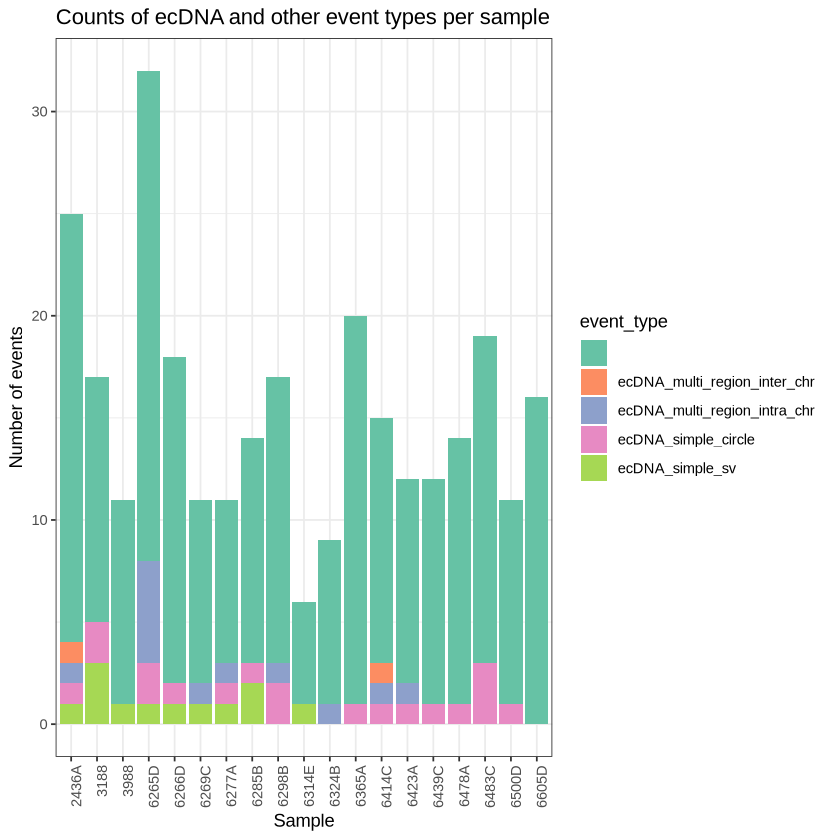

In [9]:
# Create a new column for plotting
ecdna <- ecdna %>%
  mutate(event_type = ifelse(label == "ecDNA",
                             paste(label, topology_name, sep="_"),
                             label))

# Count events per sample and event_type
type_counts <- ecdna %>%
  group_by(sample, event_type) %>%
  summarise(count = n(), .groups="drop")

# Stacked bar plot
ggplot(type_counts, aes(x=sample, y=count, fill=event_type)) +
  geom_bar(stat="identity", position="stack") +
  theme_bw() +
  xlab("Sample") +
  ylab("Number of events") +
  ggtitle("Counts of ecDNA and other event types per sample") +
  theme(axis.text.x = element_text(angle=90, hjust=1)) +
  scale_fill_brewer(palette = "Set2")







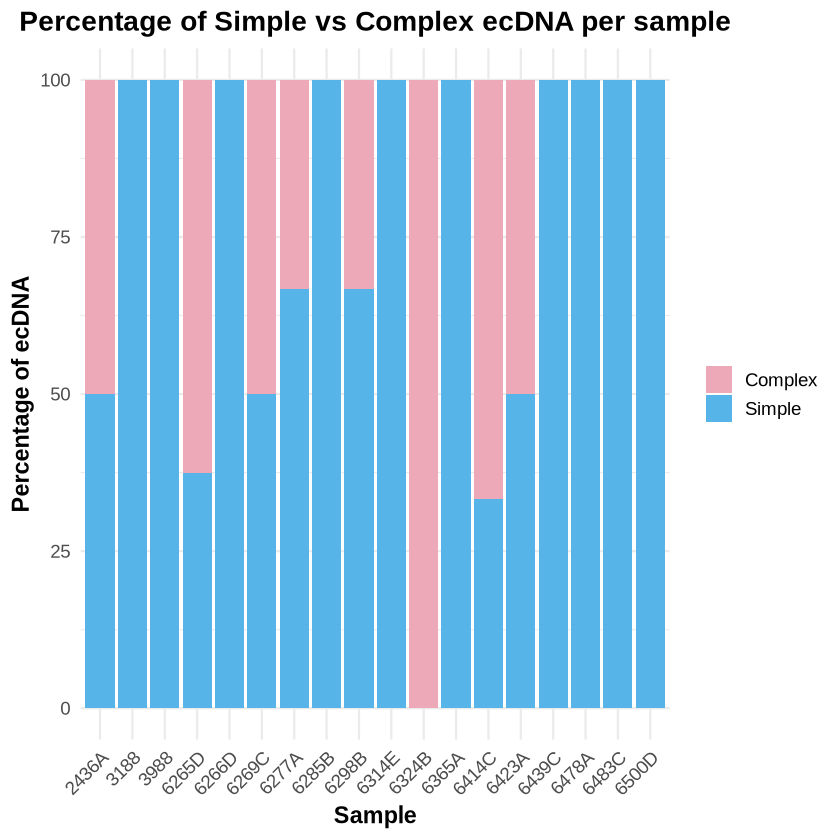

In [10]:
library(dplyr)
library(ggplot2)
library(ggsci)

# ----------------------------
# 1️⃣ Filter only high-confidence ecDNA and categorize
# ----------------------------
ecdna_ec <- ecdna %>%
  filter(label == "ecDNA") %>%
  mutate(ec_type = case_when(
    grepl("simple", topology_name, ignore.case = TRUE) ~ "Simple",
    TRUE ~ "Complex"
  ))

# ----------------------------
# 2️⃣ Count number per sample and type
# ----------------------------
ec_counts <- ecdna_ec %>%
  group_by(sample, ec_type) %>%
  summarise(count = n(), .groups="drop")

# ----------------------------
# 3️⃣ Compute percentages per sample
# ----------------------------
ec_percent <- ec_counts %>%
  group_by(sample) %>%
  mutate(perc = count / sum(count) * 100)

# ----------------------------
# 4️⃣ Stacked bar plot
# ----------------------------
ggplot(ec_percent, aes(x=sample, y=perc, fill=ec_type)) +
  geom_bar(stat="identity") +
  scale_fill_manual(values=c("Simple"="#56B4E9", "Complex"="pink2")) +
  theme_minimal(base_size=14) +
  ylab("Percentage of ecDNA") +
  xlab("Sample") +
  ggtitle("Percentage of Simple vs Complex ecDNA per sample") +
  theme(
    plot.title = element_text(face="bold", hjust=0.5),
    axis.text.x = element_text(angle=45, hjust=1),
    axis.title = element_text(face="bold"),
    legend.title = element_blank()
  )

# ----------------------------
# 5️⃣ Optional: save plot
# ----------------------------


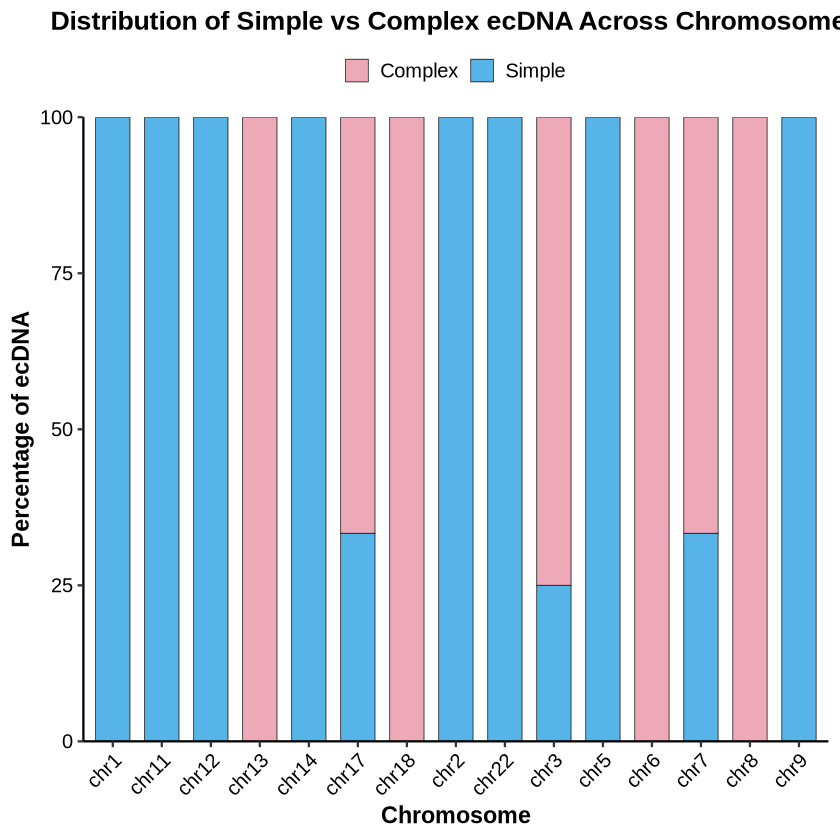

In [11]:
library(dplyr)
library(ggplot2)
library(ggsci)
library(tidyr)

# ----------------------------
# Filter high-confidence ecDNA and categorize
# ----------------------------
ecdna_ec <- ecdna %>%
  filter(label == "ecDNA") %>%
  mutate(ec_type = case_when(
    grepl("simple", topology_name, ignore.case = TRUE) ~ "Simple",
    TRUE ~ "Complex"
  ))

# ----------------------------
# Handle multi-chromosome ecDNA
# ----------------------------
ecdna_chrom <- ecdna_ec %>%
  tidyr::separate_rows(chr_origin, sep = ",")  

# ----------------------------
# Count number per chromosome and type
# ----------------------------
ec_counts_chr <- ecdna_chrom %>%
  group_by(chr_origin, ec_type) %>%
  summarise(count = n(), .groups="drop")

# ----------------------------
# Compute percentages per chromosome
# ----------------------------
ec_percent_chr <- ec_counts_chr %>%
  group_by(chr_origin) %>%
  mutate(perc = count / sum(count) * 100)

# ----------------------------
# Nature Genetics style stacked bar plot
# ----------------------------
ggplot(ec_percent_chr, aes(x=chr_origin, y=perc, fill=ec_type)) +
  geom_bar(stat="identity", width=0.7, color="black", linewidth=0.2) +
  scale_fill_manual(values=c("Simple"="#56B4E9", "Complex"="pink2")) +
  theme_classic(base_size=14) +  # clean background
  theme(
    plot.title = element_text(face="bold", size=16, hjust=0.5),
    axis.text.x = element_text(angle=45, hjust=1, size=12, color="black"),
    axis.text.y = element_text(size=12, color="black"),
    axis.title = element_text(face="bold", size=14),
    legend.position = "top",
    legend.text = element_text(size=12),
    legend.key.size = unit(0.5, "cm")
  ) +
  ylab("Percentage of ecDNA") +
  xlab("Chromosome") +
  ggtitle("Distribution of Simple vs Complex ecDNA Across Chromosomes") +
  guides(fill = guide_legend(title=NULL)) +
  scale_y_continuous(expand=c(0,0), limits=c(0,100))  # optional: 0-100%


In [12]:
ecdna_counts <- ecdna %>%
  filter(label == "ecDNA") %>%
  group_by(sample) %>%
  summarise(ecDNA_count = n(), .groups="drop")

print("Number of ecDNA reconstructions per sample:")
print(ecdna_counts)

[1] "Number of ecDNA reconstructions per sample:"
# A tibble: 18 × 2
   sample ecDNA_count
   <chr>        <int>
 1 2436A            4
 2 3188             5
 3 3988             1
 4 6265D            8
 5 6266D            2
 6 6269C            2
 7 6277A            3
 8 6285B            3
 9 6298B            3
10 6314E            1
11 6324B            1
12 6365A            1
13 6414C            3
14 6423A            2
15 6439C            1
16 6478A            1
17 6483C            3
18 6500D            1


In [13]:
# Ensure last column is sample
#colnames(ecbed)[ncol(ecbed)] <- "sample"

ecbed_counts <- ecbed %>%
  group_by(sample) %>%
  summarise(fragments_count = n(), .groups="drop")

print("Number of ecDNA fragments per sample:")
print(ecbed_counts)

[1] "Number of ecDNA fragments per sample:"
# A tibble: 19 × 2
   sample fragments_count
   <chr>            <int>
 1 2436A               12
 2 3188                 9
 3 3988                 4
 4 6265D               19
 5 6266D                4
 6 6269C                6
 7 6277A                8
 8 6285B                6
 9 6298B                7
10 6314E                3
11 6324B                4
12 6365A                2
13 6414C               17
14 6423A                6
15 6439C                2
16 6478A                2
17 6483C                4
18 6500D                2
19 6605D                1


In [14]:
# Remove rows where chr column starts with '#'
ecbed <- ecbed[!grepl("^#", ecbed$chr), ]
# Count fragments per chromosome (overall)
chrom_counts <- ecbed %>%
  group_by(chr) %>%
  summarise(fragment_count = n(), .groups="drop") %>%
  arrange(desc(fragment_count))  # optional: sort by count

# Convert chr to factor with levels in descending order
chrom_counts$chr <- factor(chrom_counts$chr, levels = chrom_counts$chr)

# Plot
p<- ggplot(chrom_counts, aes(x = chr, y = fragment_count)) +
  geom_bar(stat="identity", fill="gold") +
  theme_classic() +
  xlab("Chromosome") +
  ylab("Number of ecDNA fragments") +
  ggtitle("Overall Distribution of ecDNA Fragments per Chromosome") +
  theme(axis.text.x = element_text(angle=90, hjust=1))

ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/No_ecDNA_Fragments_chr.pdf",
  plot = p,
  width = 5, height = 5, units = "in",
  dpi = 300
)




In [15]:
# Count number of ecDNA fragments per sample
fragment_counts <- ecbed %>%
  group_by(sample) %>%
  summarise(fragments_count = n(), .groups="drop") %>%
  arrange(desc(fragments_count))

# Convert sample to factor to preserve descending order
fragment_counts$sample <- factor(fragment_counts$sample, levels = fragment_counts$sample)

# Plot
p <- ggplot(fragment_counts, aes(x = sample, y = fragments_count)) +
  geom_bar(stat="identity", fill="gold") +
  theme_classic() +
  xlab("Sample") +
  ylab("Number of ecDNA fragments") +
  ggtitle("Number of ecDNA Fragments per Sample (Filtered Data)") +
  theme(axis.text.x = element_text(angle=90, hjust=1))



ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/No_ecDNA_Fragments_Sample.pdf",
  plot = p,
  width = 5, height = 5, units = "in",
  dpi = 300
)




In [16]:
library(ggplot2)
library(dplyr)
library(forcats)
library(scales)

# Example: assume your data is in a data.frame called ec_data
# ec_data <- read.csv("your_file.csv")  # or already in R

# 1️⃣ Calculate ecDNA size in kb
ec_summary <- ecbed %>%
  mutate(
    start = as.numeric(start),
    end = as.numeric(end),
    size_kb = (end - start + 1)/1000  # convert bp to kb
  ) %>%
  filter(size_kb > 0)

# 2️⃣ Define size bins
size_bins <- c(0, 50, 100, 500, 1000, 5000, 10000, Inf)  # in kb
bin_labels <- c("<50 kb", "50-100 kb", "100-500 kb", "0.5-1 Mb", "1-5 Mb", "5-10 Mb", ">10 Mb")

ec_summary <- ec_summary %>%
  mutate(size_range = cut(size_kb, breaks = size_bins, labels = bin_labels, include.lowest = TRUE))

# 3️⃣ Count per size bin
ec_bins <- ec_summary %>%
  group_by(size_range) %>%
  summarise(count = n(), .groups="drop") %>%
  mutate(perc = count / sum(count) * 100)

# 4️⃣ Bar plot per size range
p <- ggplot(ec_bins, aes(x=size_range, y=count, fill=fct_reorder(size_range, -count))) +
  geom_col(color="black", width=0.7) +
  geom_text(aes(label=paste0(count, " (", round(perc,1), "%)")), 
            vjust=-0.5, size=3.5) +
  scale_fill_manual(values = c(
    "<50 kb" = "#FFF7BC",
    "50-100 kb" = "#FEE391",
    "100-500 kb" = "#FEC44F",
    "0.5-1 Mb" = "#FE9929",
    "1-5 Mb" = "#EC7014",
    "5-10 Mb" = "#CC4C02",
    ">10 Mb" = "#993404"
  )) +
  ylab("Number of ecDNA circles") +
  xlab("ecDNA size range") +
  ggtitle("Distribution of ecDNA sizes across the cohort") +
  theme_classic(base_size=14) +
  theme(
    plot.title = element_text(face="bold", hjust=0.5),
    axis.title = element_text(face="bold"),
    axis.text.x = element_text(angle=45, hjust=1),
    legend.position = "none"
  )

ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/size_ecDNA_Fragments.pdf",
  plot = p,
  width = 5, height = 5, units = "in",
  dpi = 300
)




Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




In [17]:
# ===== Packages =====
suppressPackageStartupMessages({
  library(dplyr)
  library(stringr)
  library(tidyr)
  library(readr)         # for parse_number()
  library(GenomicRanges)
  library(IRanges)
})

options(stringsAsFactors = FALSE)

# ───────────────────────────────────────────────────────────────────────────────
# 0) Clean inputs and harmonize column names
# ───────────────────────────────────────────────────────────────────────────────

# Replace your chr_arm_size2 block with this:
chr_arm_size2 <- chr_arm_size %>%
  mutate(
    Chromosome = stringr::str_trim(Chromosome),
    Start  = as.integer(Start),
    End    = as.integer(End),
    Arm    = stringr::str_trim(Arm)
  ) %>%
  transmute(
    Chromosome, Start, End, Arm,
    ArmLen = End - Start   # compute directly; matches your table (no +1)
  )

# arms_gr stays the same but uses the computed ArmLen:
arms_gr <- GenomicRanges::GRanges(
  seqnames = chr_arm_size2$Chromosome,
  ranges   = IRanges::IRanges(start = chr_arm_size2$Start + 1L, end = chr_arm_size2$End),
  Arm      = chr_arm_size2$Arm,
  ArmLen   = chr_arm_size2$ArmLen
)

# and this later snippet will now work as-is:
arm_len_tbl <- chr_arm_size2 %>%
  dplyr::mutate(chr_arm_tel = paste0(Chromosome, Arm)) %>%
  dplyr::select(chr_arm_tel, ArmLen)


# ecbed: robustly parse start/end even if they arrive as "145478082" or "145478082.0"
ecbed2 <- ecbed %>%
  mutate(
    chr    = str_trim(chr),
    start  = suppressWarnings(as.integer(parse_number(start))),
    end    = suppressWarnings(as.integer(parse_number(end))),
    sample = str_trim(sample)
  ) %>%
  filter(!is.na(start), !is.na(end), start < end)

# telomeres: keep only requested telomere metrics
tel_sub <- telomeres_MAD %>%
  transmute(
    Sample_prefix = str_trim(Sample_prefix),
    chr_arm_tel   = str_trim(chr),                 # e.g., "chr1p"
    TL_kb         = final_average_TL_p75_kb,       # telomere length (kb)
    norm_TL       = norm_TL                        # normalized telomere length (MAD-based)
  )

# ───────────────────────────────────────────────────────────────────────────────
# 1) Assign p/q arms to ecDNA intervals (max-overlap if spanning)
#    NOTE: BED-like 'start' is 0-based; GRanges is 1-based → add +1 to start.
# ───────────────────────────────────────────────────────────────────────────────

arms_gr <- GRanges(
  seqnames = chr_arm_size2$Chromosome,
  ranges   = IRanges(start = chr_arm_size2$Start + 1L, end = chr_arm_size2$End),
  Arm      = chr_arm_size2$Arm,
  ArmLen   = chr_arm_size2$ArmLen
)

ec_gr <- GRanges(
  seqnames = ecbed2$chr,
  ranges   = IRanges(start = ecbed2$start + 1L, end = ecbed2$end)
)

hits <- findOverlaps(ec_gr, arms_gr, type = "any")
if (length(hits) == 0L) {
  stop("No overlaps found between ecDNA intervals and chromosome arms. Check coordinate systems.")
}

# choose, for each ecDNA interval, the arm with the largest overlap
ovl_tbl <- tibble(
  i = queryHits(hits),
  j = subjectHits(hits),
  ovl_bp = width(pintersect(ranges(ec_gr)[queryHits(hits)], ranges(arms_gr)[subjectHits(hits)]))
) %>%
  group_by(i) %>%
  slice_max(order_by = ovl_bp, n = 1, with_ties = FALSE) %>%
  ungroup()

ec_with_arm <- ecbed2[ovl_tbl$i, ] %>%
  bind_cols(
    tibble(
      Chromosome = as.character(seqnames(arms_gr)[ovl_tbl$j]),
      Arm        = mcols(arms_gr)$Arm[ovl_tbl$j],
      ArmLen     = mcols(arms_gr)$ArmLen[ovl_tbl$j]
    )
  ) %>%
  mutate(
    chr_arm = paste0(Chromosome, Arm)  # e.g., "chr7q"
  )

# ───────────────────────────────────────────────────────────────────────────────
# 2) Merge with telomere metrics (keep ONLY TL_kb and norm_TL)
# ───────────────────────────────────────────────────────────────────────────────

ec_tel_merged <- ec_with_arm %>%
  mutate(
    Sample_prefix = sample,
    chr_arm_tel   = chr_arm
  ) %>%
  left_join(tel_sub, by = c("Sample_prefix", "chr_arm_tel")) %>%
  select(sample, Chromosome, Arm, chr_arm, start, end, TL_kb, norm_TL, ArmLen, estimated_proportions, fragment_id, circ_id )

# ───────────────────────────────────────────────────────────────────────────────
# 3) Label presence/absence per Sample × Arm:
#    Group: 'ecDNA' if any circle on that arm; else 'noecDNA'
#    color: 'ecDNA' for present; NA for absent
# ───────────────────────────────────────────────────────────────────────────────

# universe of (Sample, Arm) from the telomere table
all_arms <- tel_sub %>%
  distinct(Sample_prefix, chr_arm_tel)

# where ecDNA exists (deduplicate intervals just in case)
ec_presence <- ec_with_arm %>%
  distinct(sample, chr_arm) %>%
  transmute(Sample_prefix = sample, chr_arm_tel = chr_arm, Group = "ecDNA")

presence_labeled <- all_arms %>%
  left_join(ec_presence, by = c("Sample_prefix", "chr_arm_tel")) %>%
  mutate(
    Group = if_else(is.na(Group), "noecDNA", Group),
    color = if_else(Group == "ecDNA", "ecDNA", NA_character_)
  ) %>%
  left_join(tel_sub, by = c("Sample_prefix", "chr_arm_tel"))
# Columns here: Sample_prefix, chr_arm_tel, Group, color, TL_kb, norm_TL

# ───────────────────────────────────────────────────────────────────────────────
# 4) Per-arm counts and rates
#    - ecDNA_count: number of ecDNA intervals on that arm
#    - ecDNA_per_Mb: count normalized by arm length (Mb)
#    - prop_within_sample: share of a sample’s ecDNA assigned to that arm
#    For 'noecDNA' rows, set ecDNA_count and ecDNA_per_Mb to NA (per your request)
# ───────────────────────────────────────────────────────────────────────────────

arm_len_tbl <- chr_arm_size2 %>%
  mutate(chr_arm_tel = paste0(Chromosome, Arm)) %>%
  select(chr_arm_tel, ArmLen)

# Count distinct intervals per arm to avoid double-counting exact duplicates
ec_counts_raw <- ec_with_arm %>%
  distinct(sample, chr_arm, start, end) %>%
  count(Sample_prefix = sample, chr_arm_tel = chr_arm, name = "ecDNA_count")

per_arm_counts <- all_arms %>%
  left_join(ec_counts_raw, by = c("Sample_prefix", "chr_arm_tel")) %>%
  mutate(ecDNA_count = replace_na(ecDNA_count, 0L)) %>%
  left_join(arm_len_tbl, by = "chr_arm_tel") %>%
  mutate(
    arm_len_Mb   = ArmLen / 1e6,
    ecDNA_per_Mb = if_else(arm_len_Mb > 0, ecDNA_count / arm_len_Mb, NA_real_),
    Group        = if_else(ecDNA_count > 0, "ecDNA", "noecDNA"),
    color        = if_else(ecDNA_count > 0, "ecDNA", NA_character_)
  ) %>%
  # add telomere metrics, then keep ONLY TL_kb and norm_TL from tel table
  left_join(tel_sub, by = c("Sample_prefix", "chr_arm_tel")) %>%
  select(Sample_prefix, chr_arm_tel, Group, color,
         ecDNA_count, ecDNA_per_Mb, TL_kb, norm_TL)

# Within-sample proportion (how ecDNA is distributed across arms)
per_arm_counts <- per_arm_counts %>%
  group_by(Sample_prefix) %>%
  mutate(
    total_ecDNA_in_sample = sum(replace_na(ecDNA_count, 0L)),
    prop_within_sample    = if_else(total_ecDNA_in_sample > 0,
                                    ecDNA_count / total_ecDNA_in_sample, NA_real_)
  ) %>%
  ungroup() %>%
  select(-total_ecDNA_in_sample)

# Set metrics to NA for the 'noecDNA' group (per your instruction)
per_arm_counts <- per_arm_counts %>%
  mutate(
    ecDNA_count = if_else(Group == "noecDNA", NA_integer_, ecDNA_count),
    ecDNA_per_Mb = if_else(Group == "noecDNA", NA_real_, ecDNA_per_Mb),
    prop_within_sample = if_else(Group == "noecDNA", NA_real_, prop_within_sample)
  )

# ───────────────────────────────────────────────────────────────────────────────
# 5) Per-sample ecDNA rate (fraction of arms with any ecDNA)
# ───────────────────────────────────────────────────────────────────────────────

sample_rate <- per_arm_counts %>%
  mutate(has_ecDNA = !is.na(ecDNA_count) & ecDNA_count > 0) %>%
  group_by(Sample_prefix) %>%
  summarise(
    arms_with_ecDNA = sum(has_ecDNA),
    total_arms      = n(),
    ecDNA_rate      = arms_with_ecDNA / total_arms
  ) %>%
  ungroup()

# ───────────────────────────────────────────────────────────────────────────────
# Key outputs:
#   ec_with_arm      : ecDNA intervals with assigned p/q arm + chr_arm
#   ec_tel_merged    : ecDNA intervals + (TL_kb, norm_TL) ONLY
#   presence_labeled : one row per Sample × Arm with Group (ecDNA/noecDNA), color, TL_kb, norm_TL
#   per_arm_counts   : per-arm ecDNA_count, ecDNA_per_Mb, prop_within_sample, TL_kb, norm_TL
#   sample_rate      : per-sample fraction of arms containing any ecDNA (ecDNA_rate)
# ───────────────────────────────────────────────────────────────────────────────


In [18]:
head(ec_tel_merged)

,sample,Chromosome,Arm,chr_arm,start,end,TL_kb,norm_TL,ArmLen,estimated_proportions,fragment_id,circ_id
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>
1,2436A,chr1,q,chr1q,196089010,196200712,5.051167,-0.2134030,124339061,108,989.993,1
2,2436A,chr1,q,chr1q,196202843,196213045,5.051167,-0.2134030,124339061,108,1001,1
3,2436A,chr14,q,chr14q,100384316,100903138,3.490600,-1.5358237,89761231,72,12905,25
4,2436A,chr6,q,chr6q,132892661,132908593,5.896929,0.5032938,112454080,58,6365,18
5,2436A,chr7,q,chr7q,145478082,145544265,6.483083,1.0000000,98502993,58,7405.7413.7417,18
6,2436A,chr7,q,chr7q,145467433,145478082,6.483083,1.0000000,98502993,58,7401,18



Attaching package: ‘gridExtra’


The following object is masked from ‘package:BiocGenerics’:

    combine


The following object is masked from ‘package:dplyr’:

    combine




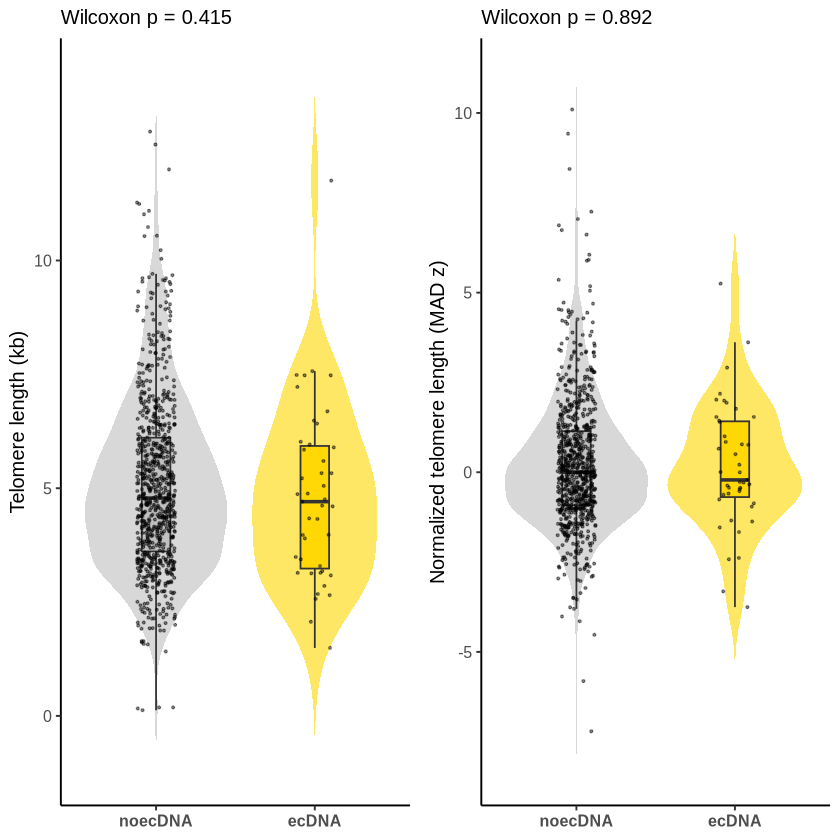

In [19]:
# Packages
library(dplyr)
library(ggplot2)
library(gridExtra)

# ---- 1) Prep data ----
# Keep rows with telomere metrics and the two groups of interest
tl_df <- presence_labeled %>%
  filter(Group %in% c("ecDNA", "noecDNA")) %>%
  filter(!is.na(TL_kb) | !is.na(norm_TL)) %>%
  mutate(Group = factor(Group, levels = c("noecDNA", "ecDNA")))  # grey first, red second

# ---- 2) Helper to make annotated violin+box plots ----
violin_box_with_p <- function(data, ycol, ylab) {
  data <- data %>% filter(!is.na(.data[[ycol]]))
  if (n_distinct(data$Group) < 2) {
    stop(paste("Need both groups present to plot", ylab, "— one of them is missing."))
  }
  pval <- tryCatch(
    wilcox.test(reformulate("Group", ycol), data = data)$p.value,
    error = function(e) NA_real_
  )
  p_lab <- if (is.na(pval)) "Wilcoxon p = NA" else paste0("Wilcoxon p = ", signif(pval, 3))

  ymax <- max(data[[ycol]], na.rm = TRUE)
  ggplot(data, aes(x = Group, y = .data[[ycol]], fill = Group)) +
    geom_violin(alpha = 0.6, trim = FALSE, color = NA) +
    geom_boxplot(width = 0.18, outlier.shape = NA, alpha = 0.95) +
    geom_jitter(width = 0.12, size = 0.5, alpha = 0.45) +
    scale_fill_manual(values = c("noecDNA" = "grey", "ecDNA" = "gold")) +
    labs(x = NULL, y = ylab, subtitle = p_lab) +
    coord_cartesian(ylim = c(NA, ymax * 1.10)) +
    theme_classic(base_size = 12) +
    theme(legend.position = "none",
          axis.text.x = element_text(face = "bold"))
}

# ---- 3) Build the two plots ----
p_kb   <- violin_box_with_p(tl_df, "TL_kb",   "Telomere length (kb)")
p_norm <- violin_box_with_p(tl_df, "norm_TL", "Normalized telomere length (MAD z)")

# Show side-by-side in the viewer (optional)
gridExtra::grid.arrange(p_kb, p_norm, ncol = 2)



In [20]:
head(per_arm_counts)

Sample_prefix,chr_arm_tel,Group,color,ecDNA_count,ecDNA_per_Mb,TL_kb,norm_TL,prop_within_sample
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
2436A,chr1p,noecDNA,NA,NA,NA,5.221000,-0.06948662,NA
2436A,chr1q,ecDNA,ecDNA,2,0.01608505,5.051167,-0.21340301,0.1666667
3188,chr1p,noecDNA,NA,NA,NA,1.642500,-2.95775970,NA
3188,chr1q,ecDNA,ecDNA,2,0.01608505,3.086500,0.65675845,0.2500000
3988,chr1p,noecDNA,NA,NA,NA,2.347500,-2.53325753,NA
3988,chr1q,noecDNA,NA,NA,NA,5.083000,-0.45973091,NA


In [21]:
head(ec_tel_merged)



,sample,Chromosome,Arm,chr_arm,start,end,TL_kb,norm_TL,ArmLen,estimated_proportions,fragment_id,circ_id
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>
1,2436A,chr1,q,chr1q,196089010,196200712,5.051167,-0.2134030,124339061,108,989.993,1
2,2436A,chr1,q,chr1q,196202843,196213045,5.051167,-0.2134030,124339061,108,1001,1
3,2436A,chr14,q,chr14q,100384316,100903138,3.490600,-1.5358237,89761231,72,12905,25
4,2436A,chr6,q,chr6q,132892661,132908593,5.896929,0.5032938,112454080,58,6365,18
5,2436A,chr7,q,chr7q,145478082,145544265,6.483083,1.0000000,98502993,58,7405.7413.7417,18
6,2436A,chr7,q,chr7q,145467433,145478082,6.483083,1.0000000,98502993,58,7401,18


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


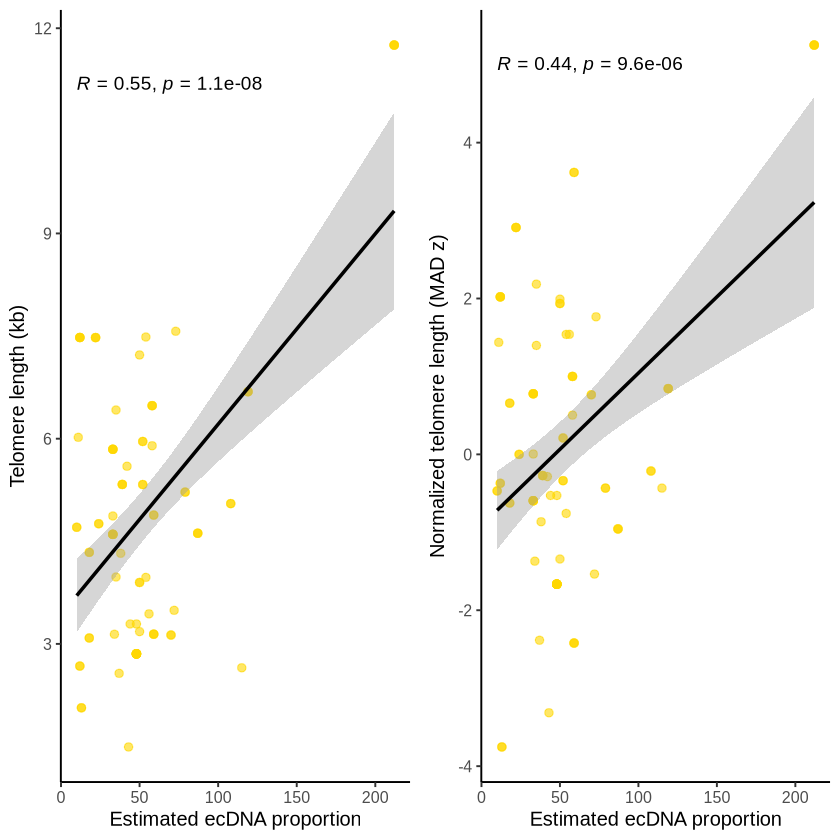

In [22]:
library(ggplot2)
library(ggpubr)

# Ensure numeric
ec_df <- ec_tel_merged %>%
  filter(!is.na(TL_kb), !is.na(norm_TL), !is.na(estimated_proportions)) %>%
  mutate(estimated_proportions = as.numeric(estimated_proportions))

# Absolute TL vs estimated ecDNA proportion
p_abs <- ggplot(ec_df, aes(x = estimated_proportions, y = TL_kb)) +
  geom_point(size = 2, alpha = 0.6, color = "gold") +  # fixed point size
  geom_smooth(method = "lm", color = "black", se = TRUE) +
  stat_cor(method = "pearson", label.x = min(ec_df$estimated_proportions),
           label.y = max(ec_df$TL_kb)*0.95, size = 4) +
  labs(x = "Estimated ecDNA proportion",
       y = "Telomere length (kb)") +
  theme_classic(base_size = 12)

# Normalized TL vs estimated ecDNA proportion
p_norm <- ggplot(ec_df, aes(x = estimated_proportions, y = norm_TL)) +
  geom_point(size = 2, alpha = 0.6, color = "gold") +
  geom_smooth(method = "lm", color = "black", se = TRUE) +
  stat_cor(method = "pearson", label.x = min(ec_df$estimated_proportions),
           label.y = max(ec_df$norm_TL, na.rm = TRUE)*0.95, size = 4) +
  labs(x = "Estimated ecDNA proportion",
       y = "Normalized telomere length (MAD z)") +
  theme_classic(base_size = 12)

# Side by side
library(gridExtra)
grid.arrange(p_abs, p_norm, ncol = 2)


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


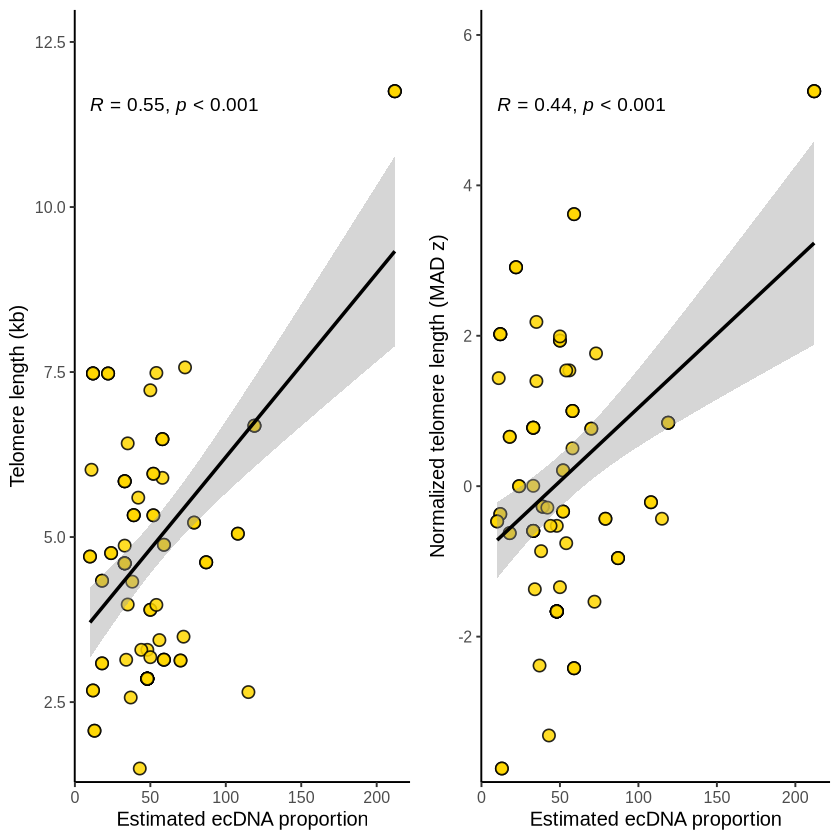

In [23]:
library(dplyr)
library(ggplot2)
library(ggpubr)
library(gridExtra)
library(scales)

# Keep a clean % variable for plotting
ec_df2 <- ec_df %>% mutate(ec_prop = estimated_proportions)

base_scatter <- function(y, ylab) {
  p <- ggplot(ec_df2, aes(x = ec_prop, y = {{ y }})) +
    geom_point(shape = 21, size = 3, stroke = 0.7,
               fill = "gold", color = "black", alpha = 0.85) +
    geom_smooth(method = "lm", se = TRUE, color = "black") +
    stat_cor(method = "pearson",
             label.x.npc = "left",  # or 0.03
             label.y.npc = "top",   # or 0.97
             r.accuracy = 0.01, p.accuracy = 0.001, size = 4) +
    #scale_x_continuous(labels = percent_format(accuracy = 1)) +
    scale_y_continuous(expand = expansion(mult = c(0.02, 0.12))) + # headroom for label
    labs(x = "Estimated ecDNA proportion", y = ylab) +
    theme_classic(base_size = 12)
}

p_abs  <- base_scatter(TL_kb,   "Telomere length (kb)")
p_norm <- base_scatter(norm_TL, "Normalized telomere length (MAD z)")

grid.arrange(p_abs, p_norm, ncol = 2)

# Arrange the two plots side by side
combined <- gridExtra::arrangeGrob(p_abs, p_norm, ncol = 2)

# Save as PDF
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/correlation_ecDNA_prop_telomeres.pdf",
  plot = combined,
  width = 8,
  height = 5,
  units = "in",
  dpi = 300
)

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“ggrepel: 7 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


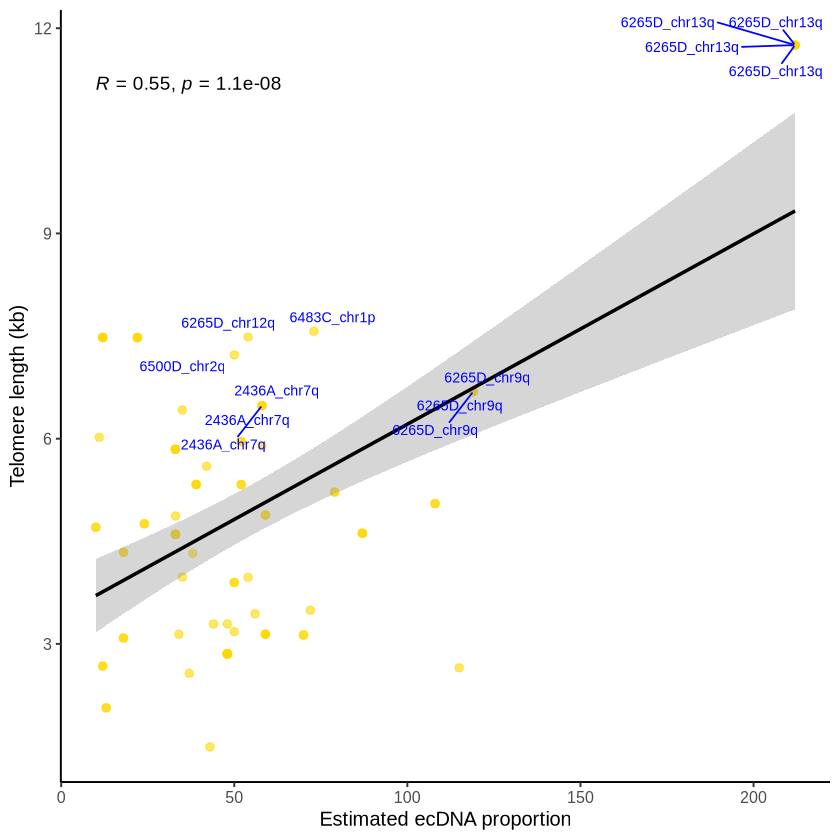

In [24]:
library(ggplot2)
library(ggrepel)
library(ggpubr)
library(dplyr)

# Make sure estimated_proportions is numeric
ec_df <- ec_tel_merged %>%
  filter(!is.na(TL_kb), !is.na(norm_TL), !is.na(estimated_proportions)) %>%
  mutate(estimated_proportions = as.numeric(estimated_proportions))

# Identify top 3 longest telomeres
top3 <- ec_df %>%
  arrange(desc(TL_kb)) %>%
  slice_head(n = 20)

# Scatter plot with regression and top 3 labels
p_abs <- ggplot(ec_df, aes(x = estimated_proportions, y = TL_kb)) +
  geom_point(size = 2, alpha = 0.6, color = "gold") +
  geom_smooth(method = "lm", color = "black", se = TRUE) +
  stat_cor(method = "pearson", label.x = min(ec_df$estimated_proportions),
           label.y = max(ec_df$TL_kb)*0.95, size = 4) +
  geom_text_repel(data = top3, 
                  aes(label = paste0(sample, "_", chr_arm)), 
                  size = 3, color = "blue", box.padding = 0.3) +
  labs(x = "Estimated ecDNA proportion",
       y = "Telomere length (kb)") +
  theme_classic(base_size = 12)

p_abs


In [25]:
head(tl_df)

,Sample_prefix,chr_arm_tel,Group,color,TL_kb,norm_TL
,<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>
1,2436A,chr1p,noecDNA,NA,5.221000,-0.06948662
2,2436A,chr1q,ecDNA,ecDNA,5.051167,-0.21340301
3,3188,chr1p,noecDNA,NA,1.642500,-2.95775970
4,3188,chr1q,ecDNA,ecDNA,3.086500,0.65675845
5,3988,chr1p,noecDNA,NA,2.347500,-2.53325753
6,3988,chr1q,noecDNA,NA,5.083000,-0.45973091


In [26]:
#test = tl_df %>%
#  filter(str_detect(Sample_prefix, "6265D|6414C|2436A|6277A"))

test = tl_df %>%
 # filter(str_detect(Sample_prefix, "6265D|6414C|2436A")) %>% 
    #filter(str_detect(chr_arm_tel, "chr1q|chr7p|chr8q|chr17q|chr9q|chr7q|chr3q"))
filter(str_detect(chr_arm_tel, "chr9"))


In [27]:
unique(test$Group)

[1] noecDNA ecDNA  
Levels: noecDNA ecDNA

In [28]:
head(test)

,Sample_prefix,chr_arm_tel,Group,color,TL_kb,norm_TL
,<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>
1,2436A,chr9p,noecDNA,NA,4.389583,-0.774027258
2,2436A,chr9q,noecDNA,NA,3.546250,-1.488666055
3,3188,chr9p,noecDNA,NA,2.822500,-0.004067584
4,3188,chr9q,ecDNA,ecDNA,3.129700,0.764893617
5,3988,chr9p,noecDNA,NA,6.700333,0.766218180
6,3988,chr9q,noecDNA,NA,9.083500,2.572673868


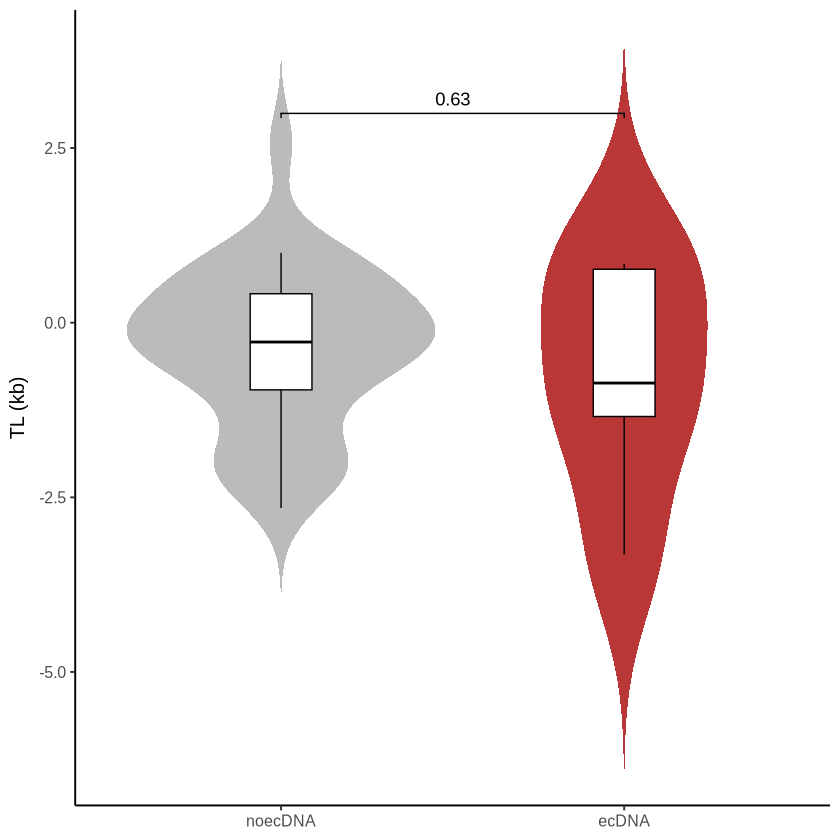

In [29]:
library(dplyr)
library(ggplot2)
library(ggpubr)

# Clean & order
test2 <- test %>%
  filter(!is.na(norm_TL), !is.na(Group)) %>%
  mutate(Group = factor(Group, levels = c("noecDNA", "ecDNA")))

y_max <- max(test2$norm_TL, na.rm = TRUE)

p <- ggplot(test2, aes(x = Group, y = norm_TL, fill = Group)) +
  geom_violin(trim = FALSE, width = 0.9, color = NA, alpha = 0.9) +
  geom_boxplot(width = 0.18, outlier.shape = NA, fill = "white", color = "black", linewidth = 0.4) +
  scale_fill_manual(values = c(noecDNA = "grey70", ecDNA = "firebrick")) +
  labs(x = NULL, y = "TL (kb)") +
  theme_classic(base_size = 12) +
  theme(legend.position = "none") +
  stat_compare_means(
    method = "t.test",
    comparisons = list(c("noecDNA", "ecDNA")),
    label = "p.format",
    hide.ns = TRUE,
    bracket.size = 0.4,
    tip.length = 0.01,
    label.y = y_max * 1.05
  )

p
# ggsave("TL_by_group_violin_pval.pdf", p, width = 4, height = 3.2, dpi = 300)


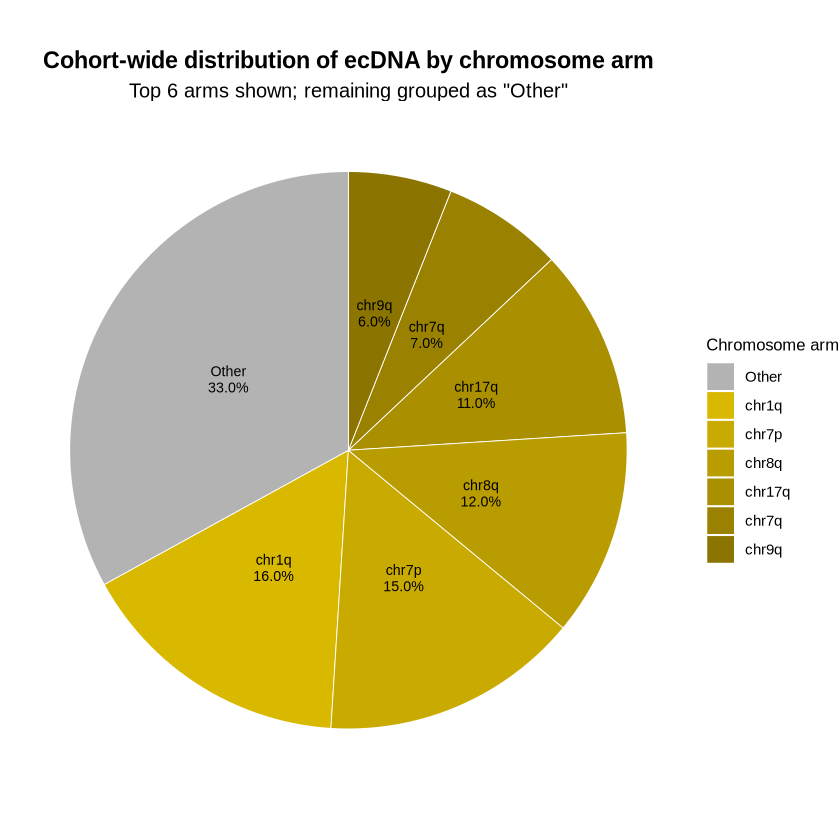

In [30]:
suppressPackageStartupMessages({
  library(dplyr)
  library(ggplot2)
  library(forcats)
  library(scales)
})

# ───────────────────────────────
# 1) Aggregate ecDNA events across the cohort
# ───────────────────────────────
cohort_counts <- ec_with_arm %>%
  distinct(sample, chr_arm, start, end) %>%  # unique intervals per sample/arm
  count(Arm = chr_arm, name = "events")      # total events per arm across cohort

# ───────────────────────────────
# 2) Keep top-N arms and lump smaller ones to "Other"
# ───────────────────────────────
top_n <- 6
min_frac_label <- 0.03

pie_df <- cohort_counts %>%
  mutate(Arm_lumped = fct_lump_n(Arm, n = top_n, w = events, other_level = "Other")) %>%
  group_by(Arm_lumped) %>%
  summarise(events = sum(events), .groups = "drop") %>%
  mutate(
    frac  = events / sum(events),
    label = if_else(frac >= min_frac_label,
                    paste0(as.character(Arm_lumped), "\n", percent(frac, accuracy = 0.1)),
                    "")
  ) %>%
  mutate(Arm_lumped = fct_reorder(Arm_lumped, events, .desc = TRUE))

# ───────────────────────────────
# 3) Generate colors: gold gradient for top arms, grey for Other
# ───────────────────────────────
arm_levels <- levels(pie_df$Arm_lumped)
top_arms <- arm_levels[arm_levels != "Other"]

# gradient gold for top arms
gold_colors <- scales::seq_gradient_pal("gold2", "gold4", "Lab")(
  seq(0.2, 1, length.out = length(top_arms))
)

# combine with grey for Other
arm_colors <- c(setNames(gold_colors, top_arms),
                Other = "grey70")

# ───────────────────────────────
# 4) Plot publication-quality pie chart
# ───────────────────────────────
p_cohort <- ggplot(pie_df, aes(x = "", y = frac, fill = Arm_lumped)) +
  geom_col(width = 1, color = "white", linewidth = 0.25) +
  coord_polar(theta = "y") +
  geom_text(aes(label = label), position = position_stack(vjust = 0.5),
            size = 3, lineheight = 0.95) +
  scale_fill_manual(values = arm_colors) +
  labs(
    title = "Cohort-wide distribution of ecDNA by chromosome arm",
    subtitle = paste0("Top ", top_n, " arms shown; remaining grouped as \"Other\""),
    fill = "Chromosome arm"
  ) +
  theme_void(base_size = 12) +
  theme(
    legend.title   = element_text(size = 10),
    legend.text    = element_text(size = 9),
    plot.title     = element_text(face = "bold", size = 14, hjust = 0.5),
    plot.subtitle  = element_text(size = 12, hjust = 0.5)
  )

print(p_cohort)

# Save as PDF
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/piechart_ecDNA_prop_per_arm.pdf",
  plot = p_cohort,
  width = 5,
  height = 5,
  units = "in",
  dpi = 300
)
# Optional: save figure
# ggsave("Cohort_ecDNA_by_arm_pie_goldGrey.pdf", p_cohort, width = 8, height = 6, useDingbats = FALSE)


In [31]:
library(readr)

clinical_data <- read_tsv("clinical_data_merged.txt", 
                          na = c("NA", "not available", ""))

# Check first rows
head(clinical_data)

Rows: 20 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): ID, surgical
dbl (9): Age, Grade, CDKN2A/B, TP53, ATRX, onco_Alterations, ONT_Alterations...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


ID,Age,Grade,CDKN2A/B,TP53,ATRX,onco_Alterations,ONT_Alterations,surgical,dead,days
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
2436A,NA,3,NA,NA,NA,5,40,NA,1,4629
3188,NA,3,NA,NA,NA,16,107,NA,1,1349
3988,0,2,2,0,0,17,105,NA,1,1536
6265D,33,3,1,0,0,42,87,NA,1,950
6266D,40,2,1,0,0,28,105,NA,1,1195
6269C,23,3,2,0,0,14,214,NA,0,2300


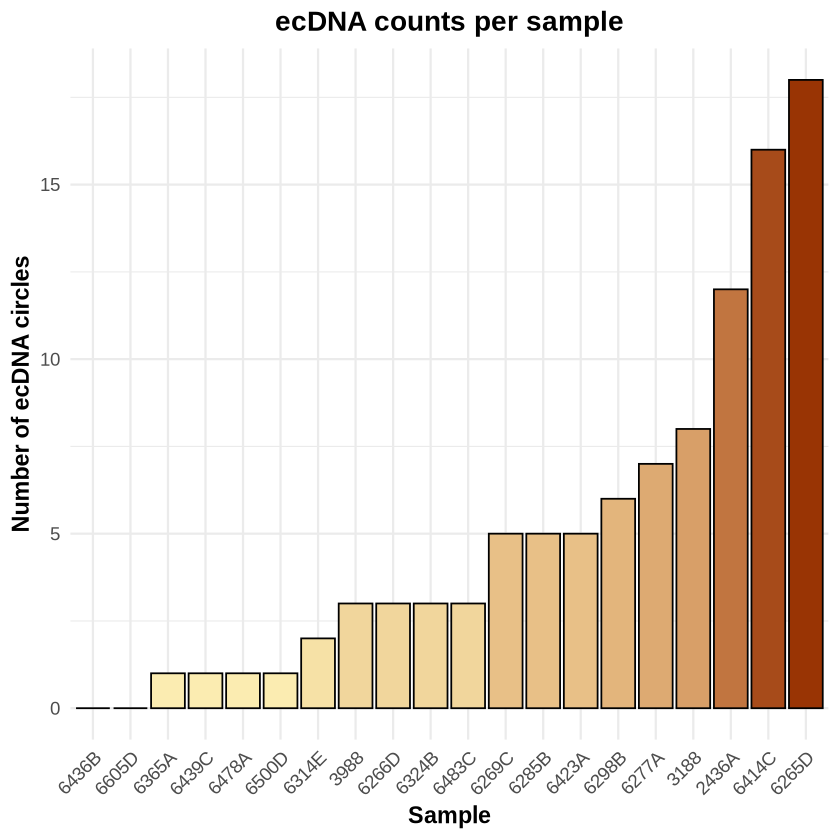

=== Spearman correlations with ecDNA counts ===
# A tibble: 1 × 7
      Age Grade `CDKN2A/B`  TP53  ATRX onco_Alterations ONT_Alterations
    <dbl> <dbl>      <dbl> <dbl> <dbl>            <dbl>           <dbl>
1 -0.0861 0.349     -0.459 0.155 0.107            0.212         -0.0464


Skipping Kruskal-Wallis for surgical - only one group present



=== Cox proportional hazards summary ===
Call:
coxph(formula = Surv(days, dead) ~ ecDNA_count + Age + Grade, 
    data = merged_data)

  n= 16, number of events= 4 
   (4 observations deleted due to missingness)

                coef exp(coef) se(coef)      z Pr(>|z|)
ecDNA_count  0.09814   1.10311  0.10540  0.931    0.352
Age         -0.04073   0.96008  0.03337 -1.221    0.222
Grade       -0.27308   0.76103  1.28018 -0.213    0.831

            exp(coef) exp(-coef) lower .95 upper .95
ecDNA_count    1.1031     0.9065    0.8972     1.356
Age            0.9601     1.0416    0.8993     1.025
Grade          0.7610     1.3140    0.0619     9.356

Concordance= 0.69  (se = 0.136 )
Likelihood ratio test= 2.49  on 3 df,   p=0.5
Wald test            = 2.26  on 3 df,   p=0.5
Score (logrank) test = 2.51  on 3 df,   p=0.5



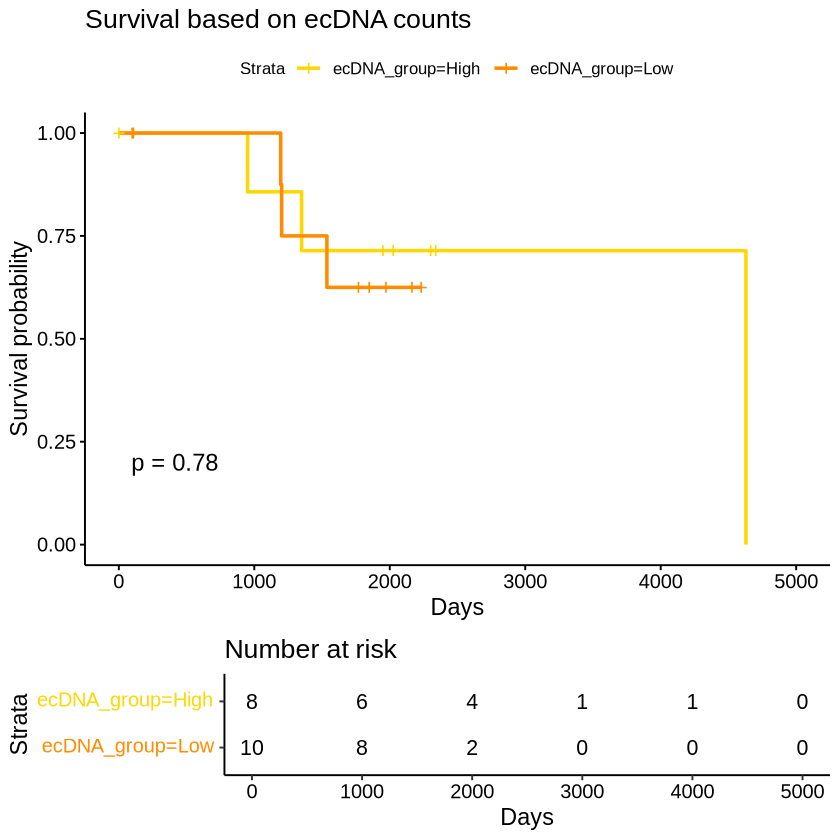

In [32]:
# ----------------------------
# Load libraries
# ----------------------------
suppressPackageStartupMessages({
  library(dplyr)
  library(ggplot2)
  library(forcats)
  library(scales)
  library(survival)
  library(survminer)
})

# ----------------------------
# 1️⃣ Count ecDNA per sample
# ----------------------------
ec_counts <- ecbed %>%
  mutate(start = as.numeric(start),
         end = as.numeric(end)) %>%
  group_by(sample) %>%
  summarise(ecDNA_count = n(), .groups="drop")

# ----------------------------
# 2️⃣ Merge with clinical data
# ----------------------------
merged_data <- clinical_data %>%
  left_join(ec_counts, by = c("ID" = "sample")) %>%
  mutate(ecDNA_count = ifelse(is.na(ecDNA_count), 0, ecDNA_count))

# ----------------------------
# 3️⃣ Barplot of ecDNA counts per sample
# ----------------------------
p_bar <- ggplot(merged_data, 
                aes(x = fct_reorder(ID, ecDNA_count), y = ecDNA_count, fill = ecDNA_count)) +
  geom_col(color="black") +
  scale_fill_gradient(low="#FFF7BC", high="#993404") +
  xlab("Sample") +
  ylab("Number of ecDNA circles") +
  ggtitle("ecDNA counts per sample") +
  theme_minimal(base_size=14) +
  theme(axis.text.x = element_text(angle=45, hjust=1),
        plot.title = element_text(face="bold", hjust=0.5),
        axis.title = element_text(face="bold"),
        legend.position="none")

print(p_bar)

# ----------------------------
# 4️⃣ Kaplan-Meier survival based on ecDNA counts
# ----------------------------
merged_data <- merged_data %>%
  mutate(ecDNA_group = ifelse(ecDNA_count > median(ecDNA_count), "High", "Low"))

surv_obj <- Surv(time = merged_data$days, event = merged_data$dead)
fit <- survfit(surv_obj ~ ecDNA_group, data = merged_data)

p_surv <- ggsurvplot(
  fit,
  data = merged_data,
  risk.table = TRUE,
  pval = TRUE,
  conf.int = FALSE,
  palette = c("gold", "darkorange"),
  title = "Survival based on ecDNA counts",
  xlab = "Days",
  ylab = "Survival probability",
  risk.table.height = 0.25
)

print(p_surv)

# ----------------------------
# 5️⃣ Continuous variable associations (Spearman)
# ----------------------------
continuous_vars <- c("Age", "Grade", "CDKN2A/B", "TP53", "ATRX", "onco_Alterations", "ONT_Alterations")

cat("=== Spearman correlations with ecDNA counts ===\n")
cor_results <- merged_data %>%
  select(all_of(continuous_vars), ecDNA_count) %>%
  summarise(across(all_of(continuous_vars), ~ cor(.x, ecDNA_count, use="complete.obs", method="spearman")))
print(cor_results)

# ----------------------------
# 6️⃣ Categorical variable associations (Boxplots + Kruskal-Wallis)
# ----------------------------
categorical_vars <- c("surgical")  # add more if needed

for(cat_var in categorical_vars){
  # Skip if less than 2 non-NA groups
  n_levels <- merged_data %>%
    filter(!is.na(.data[[cat_var]])) %>%
    pull(.data[[cat_var]]) %>%
    unique() %>% length()
  
  if(n_levels < 2){
    message(paste("Skipping Kruskal-Wallis for", cat_var, "- only one group present"))
    next
  }
  
  # Boxplot
  p <- ggplot(merged_data, aes_string(x=cat_var, y="ecDNA_count", fill=cat_var)) +
    geom_boxplot() +
    geom_jitter(width=0.2, alpha=0.6) +
    theme_minimal(base_size=14) +
    ylab("ecDNA count") +
    xlab(cat_var) +
    ggtitle(paste("ecDNA count vs", cat_var)) +
    theme(plot.title = element_text(face="bold", hjust=0.5),
          axis.title = element_text(face="bold"),
          legend.position="none")
  print(p)
  
  # Kruskal-Wallis test
  cat(paste("Kruskal-Wallis test for", cat_var, "\n"))
  print(kruskal.test(as.formula(paste("ecDNA_count ~", cat_var)), data=merged_data))
}

# ----------------------------
# 7️⃣ Optional: Cox proportional hazards
# ----------------------------
cox_fit <- coxph(Surv(days, dead) ~ ecDNA_count + Age + Grade, data = merged_data)
cat("=== Cox proportional hazards summary ===\n")
print(summary(cox_fit))


In [33]:
options(repr.plot.width = 4, repr.plot.height = 4, repr.plot.res = 200)


p_violin <- ggplot(grade_subset, aes(x = Grade, y = ecDNA_count, fill = Grade)) +
  geom_violin(trim = FALSE, width = 1.5, f = "white", alpha = 0.65) +
  geom_boxplot(width = 0.18, outlier.shape = NA, fill = "white",
               color = "black", linewidth = 0.5) +
  ggforce::geom_sina(shape = 21, size = 2, stroke = 0.7,  # <-- sina dots
                     fill = "white", alpha = 0.9, maxwidth = 0.5) +
  scale_fill_manual(values = grade_cols) +
  labs(x = "Tumor Grade", y = "ecDNA count",
       title = "ecDNA count vs Tumor Grade — Violin + boxplot") +
  theme_classic(base_size = 14) +
  theme(legend.position = "none",
        plot.title = element_text(face = "bold", hjust = 0.5)) +
  stat_compare_means(
    method = "t.test",
    comparisons = list(c("2", "3")),
    label = "p.format",
    bracket.size = 0.5,
    tip.length = 0.01,
    hide.ns = FALSE,
    label.y = y_max * 1.08
  ) +
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))
options(repr.plot.width = 3, repr.plot.height = 4, repr.plot.res = 200)

print(p_violin)
# Save as PDF
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/viloin_grades.pdf",
  plot = p_violin,
  width = 3,
  height = 4,
  units = "in",
  dpi = 300
)

ERROR: Error: object 'grade_subset' not found


In [ ]:
head(merged_data)

In [ ]:
nrow(ecbed)

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 4, repr.plot.res = 200)

In [ ]:
library(dplyr)
library(tidyr)
library(ggplot2)

ecbed_long <- ecbed %>%
  transmute(
    coverage = suppressWarnings(as.numeric(coverage)),
    estimated_proportions = suppressWarnings(as.numeric(estimated_proportions)) / 100
  ) %>%
  pivot_longer(c(coverage, estimated_proportions),
               names_to = "metric", values_to = "value") %>%
  filter(!is.na(value))

p <- ggplot(ecbed_long, aes(y = value, fill = metric)) +
  geom_violin(aes(x = ""), trim = FALSE, width = 0.9, color = NA, alpha = 0.5, fill = "gold") +
  geom_boxplot(aes(x = ""), width = 0.3, outlier.shape = NA, fill = "white",
               color = "black", linewidth = 0.5) +
  ggforce::geom_sina(aes(x = ""), shape = 21, size = 2, stroke = 0.7,
                     fill = "white", alpha = 0.3, maxwidth = 0.9) +
  facet_wrap(~ metric, scales = "free_y") +
  labs(x = NULL, y = "Value") +
  theme_classic(base_size = 13) +
  theme(legend.position = "none",
        strip.text = element_text(face = "bold"),
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank())

p
# Save as PDF
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/estimated_prop_cov.pdf",
  plot = p,
  width = 6,
  height = 4,
  units = "in",
  dpi = 300
)

In [ ]:
library(dplyr)
library(ggplot2)
library(ggforce)

# Compute ecDNA size in kb
ecbed_size <- ecbed %>%
  mutate(
    size_kb = (as.numeric(end) - as.numeric(start)) / 1000
  ) %>%
  filter(!is.na(size_kb), size_kb > 0)

# Plot
p_size_log <- ggplot(ecbed_size, aes(y = size_kb)) +
  geom_violin(aes(x = ""), trim = FALSE, width = 0.9,
              color = NA, alpha = 0.5, fill = "gold") +
  geom_boxplot(aes(x = ""), width = 0.25, outlier.shape = NA,
               fill = "white", color = "black", linewidth = 0.5) +
  ggforce::geom_sina(aes(x = ""), shape = 21, size = 2, stroke = 0.7,
                     fill = "white", alpha = 0.4, maxwidth = 0.8) +
  scale_y_log10(
    labels = scales::label_number(accuracy = 1),   # just numeric labels
    breaks = c(1, 10, 100, 1000, 10000)
  ) +
  labs(
    x = NULL,
    y = "ecDNA circle size (kb, log10 scale)",
    title = "Distribution of ecDNA Circle Sizes"
  ) +
  theme_classic(base_size = 14) +
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )
options(repr.plot.width = 4, repr.plot.height = 4, repr.plot.res = 200)
p_size_log
# Save as PDF
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/size_destributions.pdf",
  plot = p_size_log,
  width = 4,
  height = 4,
  units = "in",
  dpi = 300
)

In [ ]:
ecdna <- read.delim("all_samples_summary.tsv", sep = "\t", header = TRUE)


In [ ]:
head(ecdna)

In [ ]:
nrow(ecdna)

In [ ]:
unique(ecdna$topology_name)

In [ ]:
unique(ecdna$label)

In [ ]:
library(dplyr)
library(ggplot2)
library(ggrepel)
library(scales)

# --- Prep: collapse rows into "ecDNA" vs. their topology_name (if not ecDNA) ---
pie_df <- ecdna %>%
  mutate(
    label_clean = tolower(trimws(label)),
    category = if_else(!is.na(label_clean) & label_clean == "ecdna",
                       "ecDNA",
                       if_else(is.na(topology_name) | topology_name == "", "unknown", topology_name))
  ) %>%
  count(category, name = "n") %>%
  arrange(desc(category == "ecDNA"), desc(n)) %>%  # put ecDNA first
  mutate(
    total = sum(n),
    pct   = n / total,
    lbl   = paste0(category, " — ", percent(pct, accuracy = 0.1)),
    ypos  = cumsum(n) - n/2  # angle center for labels
  )

# Check total rows (should be 290 per your note)
total_rows <- sum(pie_df$n)
message("Total rows = ", total_rows)

# --- Colors: ecDNA = yellow; others = greys ---
non_ec <- pie_df$category[pie_df$category != "ecDNA"]
greys  <- if (length(non_ec) > 0) {
  gray.colors(length(non_ec), start = 0.85, end = 0.35)
} else character(0)

fill_map <- c(setNames("gold", "ecDNA"), setNames(greys, non_ec))

# --- Plot ---
p <- ggplot(pie_df, aes(x = 1, y = n, fill = category)) +
  geom_col(width = 1, color = "white") +
  coord_polar(theta = "y") +
  # push labels outside the pie: use x > 1 (the pie spans ~0.5–1.5 in x)
  geom_text_repel(aes(x = 1.6, y = ypos, label = lbl),
                  inherit.aes = FALSE,
                  size = 4, direction = "y",
                  segment.size = 0.3, min.segment.length = 0,
                  box.padding = 0.3, point.padding = 0.2) +
  scale_fill_manual(values = fill_map) +
  xlim(0.5, 1.8) +
  guides(fill = "none") +
  theme_void(base_size = 13) +
  ggtitle("Circle DNA features (ecDNA vs. other topologies)")

p

# If you also want to print the ecDNA percentage explicitly:
ecdna_pct <- pie_df %>% filter(category == "ecDNA") %>% pull(pct)
cat("ecDNA percentage:", percent(ecdna_pct, accuracy = 0.1), "\n")


In [ ]:
library(dplyr)
library(ggplot2)
library(ggrepel)
library(scales)

# ---- Format + classify ----
pie_df <- ecdna %>%
  mutate(
    label_clean = tolower(trimws(label)),
    topo_clean  = tolower(trimws(topology_name)),

    category = case_when(
      label_clean == "ecdna" & topo_clean != "" ~ paste0("ecDNA – ", topo_clean),
      label_clean == "ecdna" ~ "ecDNA – other",
      TRUE ~ "Small circles"
    )
  ) %>%
  count(category, name = "n") %>%
  arrange(category != "Small circles", desc(n)) %>% 
  mutate(
    total = sum(n),
    pct   = n / total,
    lbl   = paste0(category, "\n", percent(pct, accuracy = 0.1)),
    ypos  = cumsum(n) - n/2
  )

# ---- Colors ----
ec_subtypes <- grep("^ecDNA", pie_df$category, value=TRUE)
ec_cols <- colorRampPalette(c("#FFD700","#FF8C00","#B22222"))(length(ec_subtypes))
names(ec_cols) <- ec_subtypes

fill_map <- c(
  "Small circles" = "#B0B0B0",   # scientific grey
  ec_cols
)

# ---- Plot ----
p <- ggplot(pie_df, aes(x=1, y=n, fill=category)) +
  geom_col(width=1, color="white", size=0.4) +
  coord_polar(theta="y") +
  geom_text_repel(
    aes(x=1.55, y=ypos, label=lbl),
    size=4.2, fontface="bold",
    min.segment.length=0, box.padding=0.3, segment.size=0.4
  ) +
  scale_fill_manual(values=fill_map) +
  xlim(0.5, 1.8) +
  theme_void(base_size=14) +
  ggtitle("Circular DNA Landscape: ecDNA vs Small Circles") +
  theme(
    plot.title = element_text(
      face="bold", size=16, hjust=0.5,
      margin=margin(b=10)
    ),
    legend.position="none"
  )

print(p)

# ---- Print ecDNA fraction ----
ec_pct <- pie_df %>% filter(grepl("^ecDNA", category)) %>% summarise(sum(n)/sum(pie_df$n))
cat("ecDNA proportion:", percent(ec_pct[[1]], accuracy=0.1), "\n")


In [34]:
unique(ecdna$topology_name)


[1] "simple_circle"          "simple_sv"              "multi_region_inter_chr"
[4] "multi_region_intra_chr" "foldbacks"              "simple_duplications"

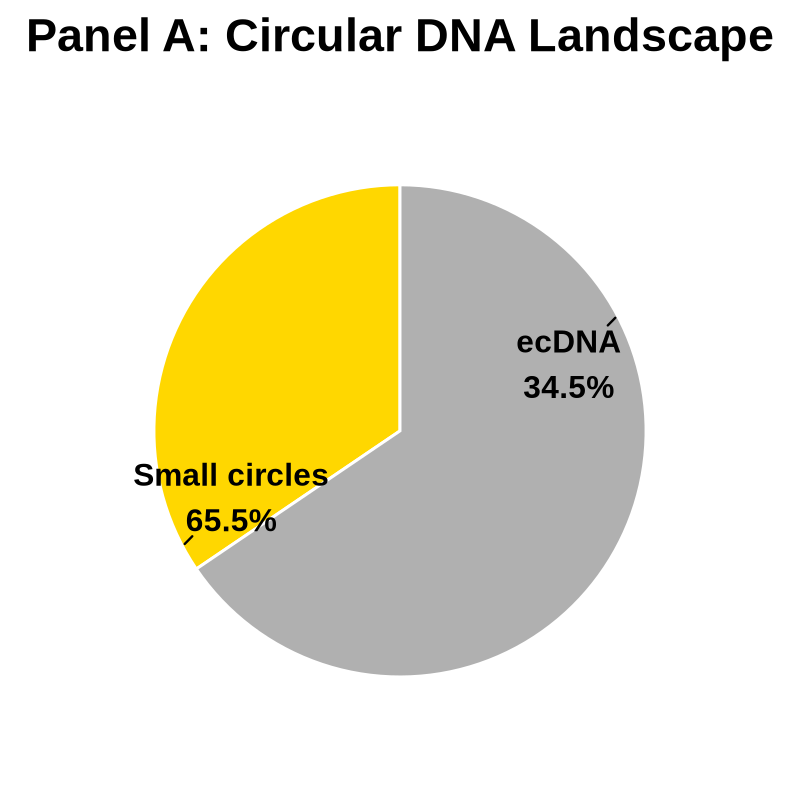

In [35]:
library(ggplot2)
library(ggrepel)
library(scales)

# ---------------------------
# Panel A: ecDNA vs Small Circles (using your data)
# ---------------------------

# Your cohort numbers
total_circles <- 290
ecDNA_count   <- 100
small_circles_count <- total_circles - ecDNA_count

# Create dataframe for plotting
pie_df <- data.frame(
  category = c("ecDNA", "Small circles"),
  n = c(ecDNA_count, small_circles_count)
) %>%
  mutate(
    total = sum(n),
    pct   = n / total,
    lbl   = paste0(category, "\n", percent(pct, accuracy=0.1)),
    ypos  = cumsum(n) - n/2
  )

# Colors
fill_map_panelA <- c(
  "ecDNA" = "#FFD700",       # gold
  "Small circles" = "#B0B0B0" # grey
)

# Plot
p_panelA <- ggplot(pie_df, aes(x=1, y=n, fill=category)) +
  geom_col(width=1, color="white") +
  coord_polar(theta="y") +
  geom_text_repel(aes(x=1.5, y=ypos, label=lbl),
                  size=4, fontface="bold", min.segment.length=0,
                  box.padding=0.3, segment.size=0.4) +
  scale_fill_manual(values=fill_map_panelA) +
  xlim(0.5,1.7) +
  theme_void(base_size=14) +
  ggtitle("Panel A: Circular DNA Landscape") +
  theme(
    plot.title = element_text(face="bold", hjust=0.5),
    legend.position="none"
  )
options(repr.plot.width = 4, repr.plot.height = 4, repr.plot.res = 200)

p_panelA
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/decoil_perc_ecdna.pdf",
  plot = p_panelA,
  width = 4,
  height = 4,
  units = "in",
  dpi = 300
)

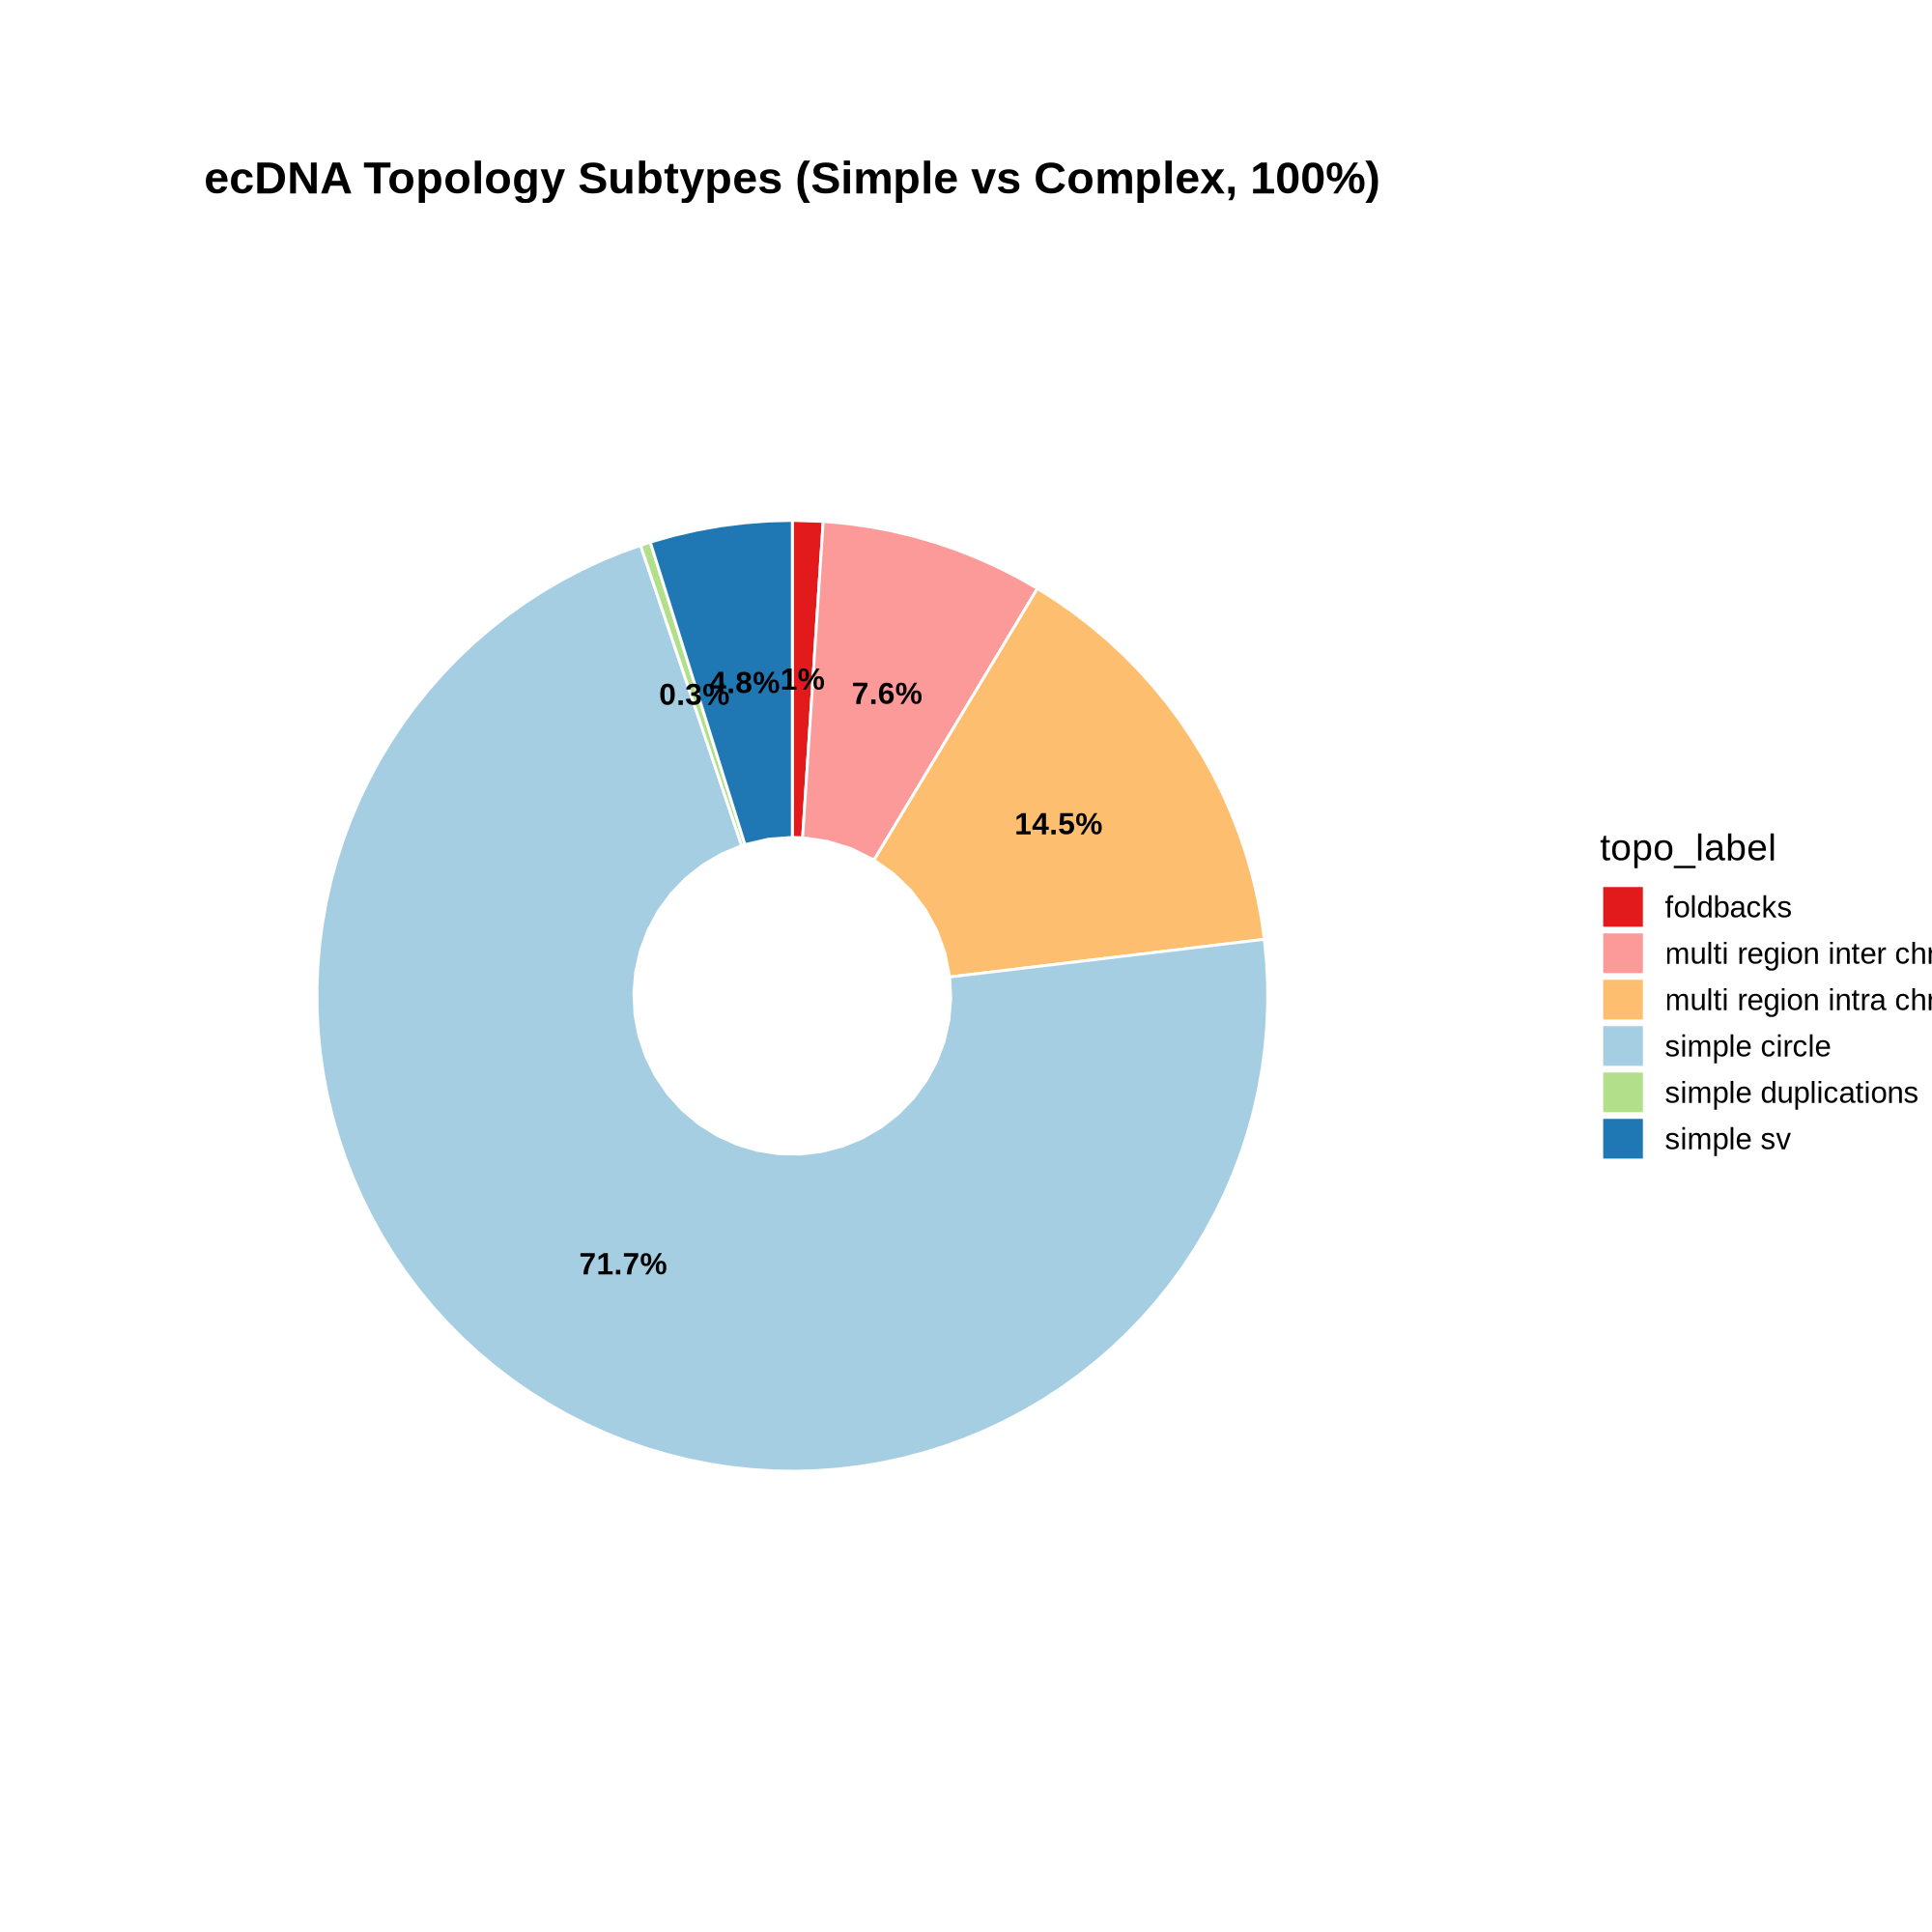

In [36]:
library(dplyr)
library(ggplot2)
library(scales)

# ---- Prepare data ----
donut_df <- ecdna %>%
  mutate(
    topo_clean = trimws(topology_name),
    group = case_when(
      topo_clean %in% c("simple_circle","simple_sv","simple_duplications") ~ "Simple",
      topo_clean %in% c("foldbacks","multi_region_inter_chr","multi_region_intra_chr") ~ "Complex",
      TRUE ~ "Other"
    )
  ) %>%
  filter(group %in% c("Simple","Complex")) %>%
  count(group, topo_clean, name="n") %>%
  group_by(group) %>%
  mutate(pct_within_group = n / sum(n)) %>%
  ungroup() %>%
  mutate(pct_total = n / sum(n)) %>%
  arrange(group)

# ---- Position for labels ----
donut_df <- donut_df %>%
  mutate(
    topo_label = gsub("_"," ", topo_clean),
    ymax = cumsum(pct_total),
    ymin = c(0, head(ymax, n=-1)),
    label_pos = (ymin + ymax)/2
  )

# ---- Updated color palette ----
topo_colors <- c(
  # Simple subtypes (pastel)
  "simple circle" = "#A6CEE3",
  "simple sv" = "#1F78B4",
  "simple duplications" = "#B2DF8A",
  # Complex subtypes (stronger)
  "foldbacks" = "#E31A1C",
  "multi region inter chr" = "#FB9A99",
  "multi region intra chr" = "#FDBF6F"
)
options(repr.plot.width = 10, repr.plot.height = 10, repr.plot.res = 200)


# ---- Plot: donut ----
p_donut <- ggplot(donut_df) +
  geom_rect(aes(ymin=ymin, ymax=ymax, xmin=1, xmax=2, fill=topo_label), color="white") +
  coord_polar(theta="y") +
  xlim(0.5, 2.5) +
  geom_text(aes(x=1.5, y=label_pos, label=paste0(round(pct_total*100,1), "%")),
            size=4, color="black", fontface="bold") +
  scale_fill_manual(values=topo_colors) +
  theme_void(base_size=14) +
  ggtitle("ecDNA Topology Subtypes (Simple vs Complex, 100%)") +
  theme(
    plot.title = element_text(face="bold", hjust=0.5),
    legend.position = "right"
  )

p_donut


In [37]:
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/decoil_perc_ecdna_subtypes.pdf",
  plot = p_donut,
  width = 10,
  height = 10,
  units = "in",
  dpi = 300
)

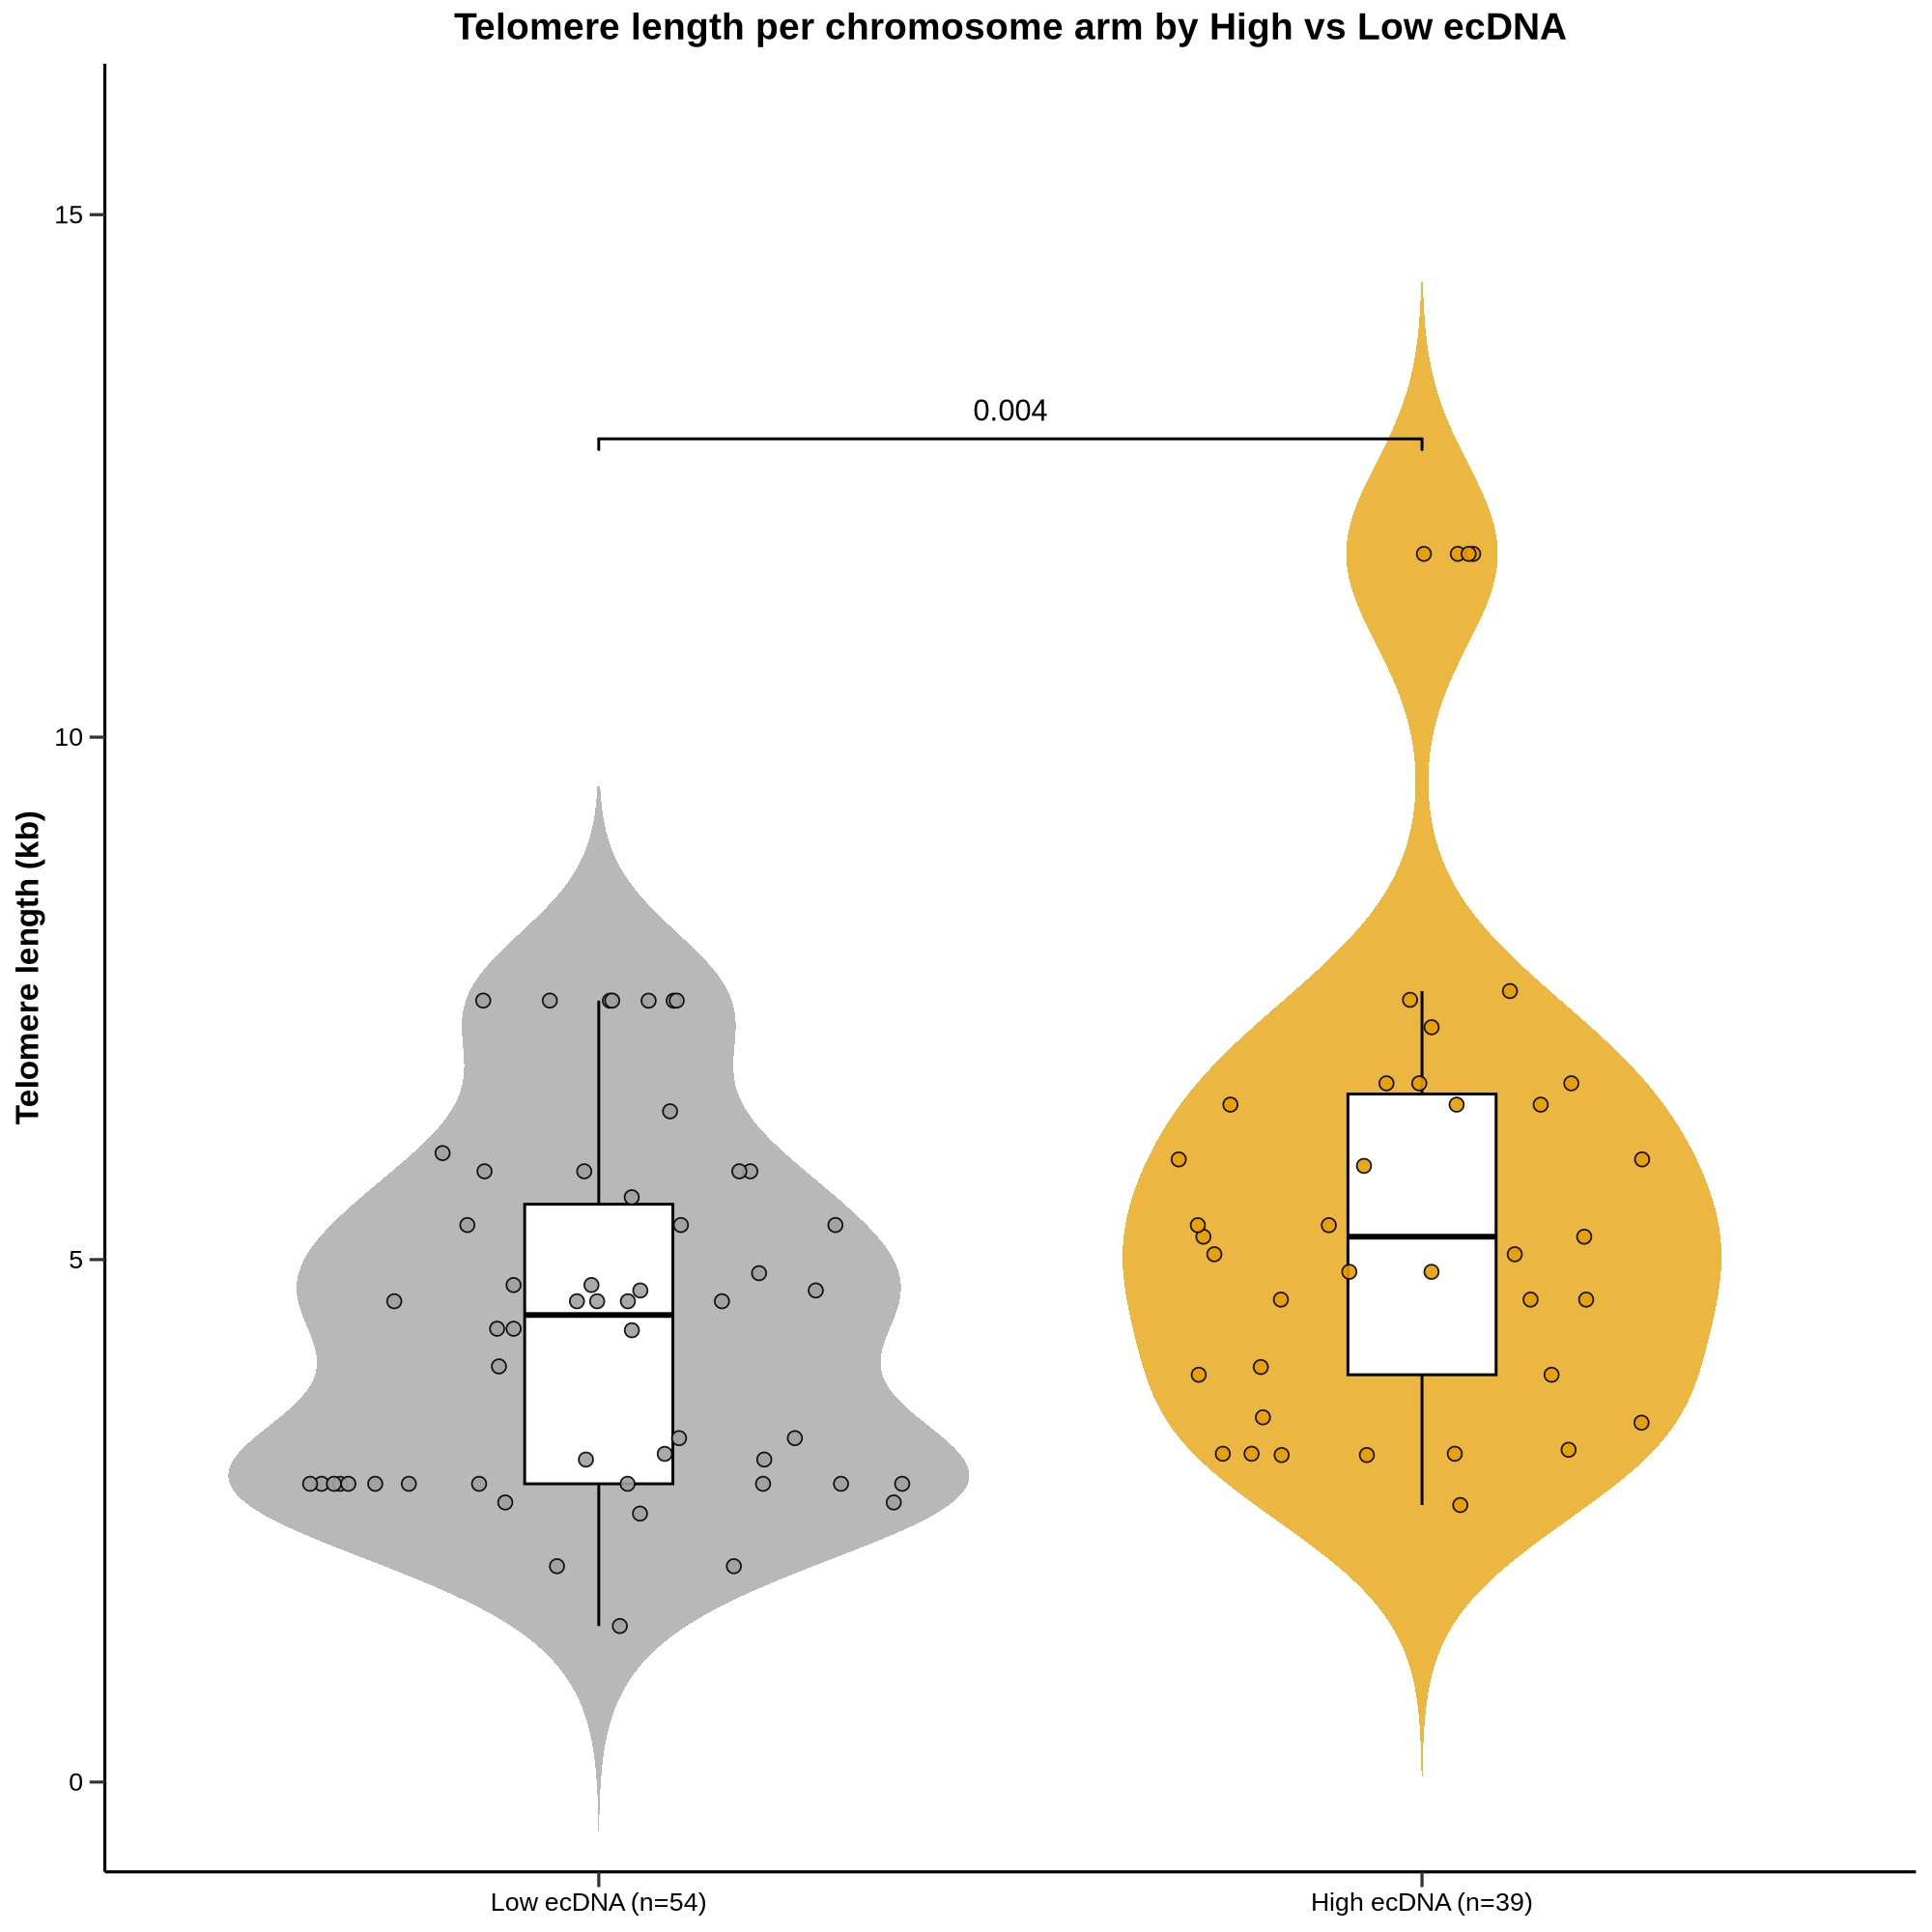

In [38]:
# ------------------------------
# Libraries
# ------------------------------
library(dplyr)
library(ggplot2)
library(ggforce)
library(ggpubr)
library(grid)  # for unit()

# ------------------------------
####### 1. Prepare data: Median-based High vs Low ecDNA (estimated_proportions > median_prop)
# ------------------------------
df_ec <- ec_tel_merged %>%
  filter(!is.na(TL_kb), !is.na(estimated_proportions)) %>%
  mutate(
    estimated_proportions = as.numeric(estimated_proportions),  # convert to numeric
    median_prop = median(estimated_proportions, na.rm = TRUE),
    prop_group = ifelse(estimated_proportions > median_prop, "High ecDNA", "Low ecDNA"),
    prop_group = factor(prop_group, levels = c("Low ecDNA", "High ecDNA"))
  )


# ------------------------------
# 2. Prepare x-axis labels with counts
# ------------------------------
x_labs <- df_ec %>%
  count(prop_group) %>%
  mutate(lab = paste0(prop_group, " (n=", n, ")")) %>%
  select(prop_group, lab) %>%
  deframe()

# ------------------------------
# 3. Determine y-axis max for Wilcoxon label
# ------------------------------
y_max <- max(df_ec$TL_kb, na.rm = TRUE)

# ------------------------------
# 4. Plot telomere lengths by High/Low ecDNA
# ------------------------------
p <- ggplot(df_ec, aes(x = prop_group, y = TL_kb, fill = prop_group)) +
  geom_violin(trim = FALSE, width = 0.9, color = NA, alpha = 0.75) +
  geom_boxplot(width = 0.18, fill = "white", outlier.shape = NA, color = "black", linewidth = 0.5) +
  ggforce::geom_sina(
    aes(fill = prop_group),   # fill points to match violin color
    shape = 21, size = 2.2, stroke = 0.45, color = "black", alpha = 0.9, maxwidth = 0.8
  ) +
  stat_compare_means(
    method = "wilcox.test",
    comparisons = list(c("Low ecDNA", "High ecDNA")),
    label = "p.format",
    bracket.size = 0.5,
    tip.length = 0.01,
    label.y = y_max * 1.05
  ) +
  scale_fill_manual(values = c("Low ecDNA" = "#A0A0A0", "High ecDNA" = "#E69F00")) +
  scale_x_discrete(labels = x_labs) +
  scale_y_continuous(expand = expansion(mult = c(0.02, 0.14))) +
  labs(
    x = NULL,
    y = "Telomere length (kb)",
    title = "Telomere length per chromosome arm by High vs Low ecDNA"
  ) +
  theme_classic(base_size = 12) +
  theme(
    legend.position = "none",
    axis.title = element_text(face = "bold"),
    axis.text = element_text(color = "black"),
    axis.ticks.length = unit(2, "mm"),
    plot.title = element_text(size = 14, face = "bold", hjust = 0.5),
    plot.margin = margin(5, 6, 5, 6)
  ) +
  coord_cartesian(clip = "off")

# ------------------------------
# 5. Display plot
# ------------------------------
p



In [39]:
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/ecdna_low_high.pdf",
  plot = p,
  width = 4,
  height = 4,
  units = "in",
  dpi = 300
)

In [40]:
head(df_ec)

,sample,Chromosome,Arm,chr_arm,start,end,TL_kb,norm_TL,ArmLen,estimated_proportions,fragment_id,circ_id,median_prop,prop_group
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>,<chr>,<chr>,<dbl>,<fct>
1,2436A,chr1,q,chr1q,196089010,196200712,5.051167,-0.2134030,124339061,108,989.993,1,48,High ecDNA
2,2436A,chr1,q,chr1q,196202843,196213045,5.051167,-0.2134030,124339061,108,1001,1,48,High ecDNA
3,2436A,chr14,q,chr14q,100384316,100903138,3.490600,-1.5358237,89761231,72,12905,25,48,High ecDNA
4,2436A,chr6,q,chr6q,132892661,132908593,5.896929,0.5032938,112454080,58,6365,18,48,High ecDNA
5,2436A,chr7,q,chr7q,145478082,145544265,6.483083,1.0000000,98502993,58,7405.7413.7417,18,48,High ecDNA
6,2436A,chr7,q,chr7q,145467433,145478082,6.483083,1.0000000,98502993,58,7401,18,48,High ecDNA


In [41]:
unique_topologies <- unique(ecdna$topology_name)
print(unique_topologies)

[1] "simple_circle"          "simple_sv"              "multi_region_inter_chr"
[4] "multi_region_intra_chr" "foldbacks"              "simple_duplications"   


In [42]:
colnames(telomere_df)


ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'colnames': object 'telomere_df' not found


In [43]:
head(ec_tel_merged)

,sample,Chromosome,Arm,chr_arm,start,end,TL_kb,norm_TL,ArmLen,estimated_proportions,fragment_id,circ_id
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>
1,2436A,chr1,q,chr1q,196089010,196200712,5.051167,-0.2134030,124339061,108,989.993,1
2,2436A,chr1,q,chr1q,196202843,196213045,5.051167,-0.2134030,124339061,108,1001,1
3,2436A,chr14,q,chr14q,100384316,100903138,3.490600,-1.5358237,89761231,72,12905,25
4,2436A,chr6,q,chr6q,132892661,132908593,5.896929,0.5032938,112454080,58,6365,18
5,2436A,chr7,q,chr7q,145478082,145544265,6.483083,1.0000000,98502993,58,7405.7413.7417,18
6,2436A,chr7,q,chr7q,145467433,145478082,6.483083,1.0000000,98502993,58,7401,18


In [44]:
library(dplyr)
library(ggplot2)
library(ggforce)
library(ggpubr)

# ------------------------------
# 1. Convert columns to correct types if needed
# ------------------------------
ec_tel_merged <- ec_tel_merged %>%
  mutate(
    circ_id = as.character(circ_id),
    fragment_id = as.character(fragment_id)
  )

topology_info <- ecdna %>%  # your second table
  mutate(circ_id = as.character(circ_id))

ecdna <- ecdna %>%
  mutate(circ_id = as.character(circ_id))

# ------------------------------
# 2. Merge by sample + circ_id
# ------------------------------
df_merged <- ec_tel_merged %>%
  left_join(
    ecdna %>% select(sample, circ_id, topology_name, topology_idx, label, size_mb),
    by = c("sample", "circ_id")
  )


# ------------------------------
# 3. Assign Simple / Complex based on number of fragments per circ_id per sample
# ------------------------------
df_merged <- df_merged %>%
  group_by(sample, circ_id) %>%
  mutate(
    n_fragments = n_distinct(fragment_id),
    ecDNA_type = ifelse(n_fragments > 1, "Complex", "Simple"),
   ecDNA_type = factor(ecDNA_type, levels = c("Simple", "Complex"))
  ) %>%
  ungroup()


# ------------------------------
# 4. Aggregate per arm (optional) for plotting
# ------------------------------
df_arm <- df_merged %>%
  group_by(sample, chr_arm, ecDNA_type) %>%
  summarise(
    mean_proportion = mean(as.numeric(estimated_proportions), na.rm = TRUE),
    median_TL = median(TL_kb, na.rm = TRUE),
    .groups = "drop"
  )


# Check merge
head(df_merged)

ERROR: [1m[33mError[39m in `select()`:[22m
[33m![39m Can't select columns that don't exist.
[31m✖[39m Column `size_mb` doesn't exist.


In [45]:
colnames(ecdna)


[1] "sample"                "circ_id"               "chr_origin"           
[4] "size.MB."              "label"                 "topology_idx"         
[7] "topology_name"         "estimated_proportions" "event_type"

`geom_smooth()` using formula = 'y ~ x'


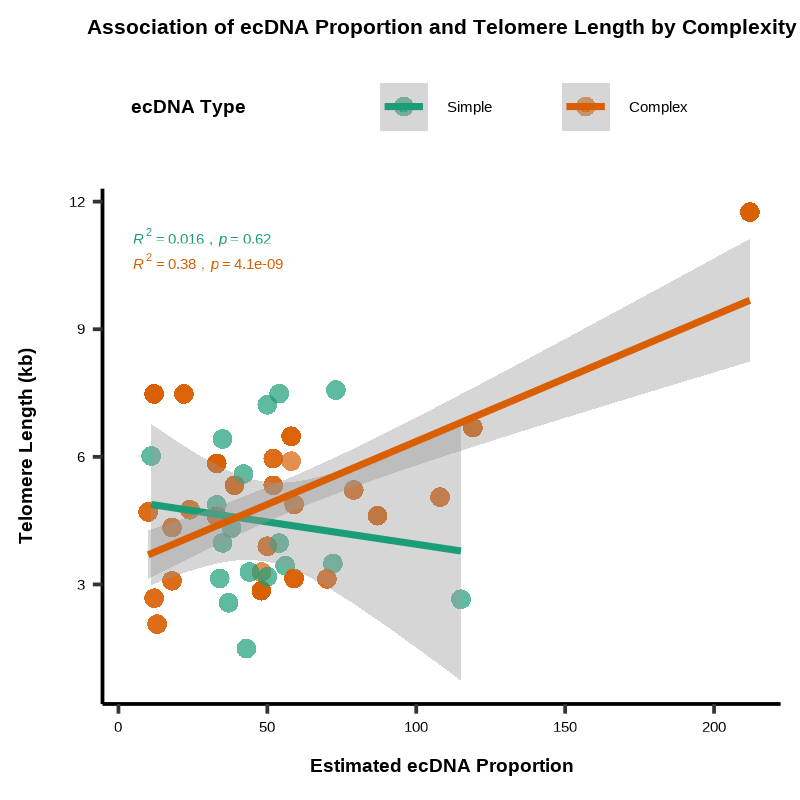

In [932]:
library(dplyr)
library(ggplot2)
library(ggpubr)

# ------------------------------
# 1. Prepare data
# ------------------------------
df_plot <- df_merged %>%
  filter(!is.na(TL_kb), !is.na(estimated_proportions), !is.na(ecDNA_type)) %>%
  mutate(ecDNA_type = factor(ecDNA_type, levels = c("Simple", "Complex")))

# ------------------------------
# 2. Scatterplot with enhanced publication-quality style
# ------------------------------
p <- ggplot(df_plot, aes(x = as.numeric(estimated_proportions), y = TL_kb, color = ecDNA_type)) +
  geom_point(alpha = 0.7, size = 3, shape = 16) +  # slightly larger, solid points
  geom_smooth(method = "lm", se = TRUE, aes(color = ecDNA_type), linewidth = 1.2) +
  stat_cor(
    aes(label = paste(..rr.label.., ..p.label.., sep = "~`,`~")),
    method = "pearson",
    label.x = 5, label.y.npc = 0.95,
    size = 4
  ) +
  scale_color_manual(values = c("Simple" = "#1b9e77", "Complex" = "#d95f02")) +  # Teal and Orange
  labs(
    x = "Estimated ecDNA Proportion",
    y = "Telomere Length (kb)",
    color = "ecDNA Type",
    title = "Association of ecDNA Proportion and Telomere Length by Complexity"
  ) +
  theme_classic(base_size = 14) +
  theme(
    legend.position = "top",
    legend.title = element_text(face = "bold"),
    plot.title = element_text(face = "bold", hjust = 0.5, size = 16),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(color = "black")
  )

p


In [909]:
# Save as a PDF with editable text and publication-quality settings
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/ecDNA_telomere_complexity.pdf",  # output filename
  plot = p,                              # the ggplot object
  #device = cairo_pdf,                     # ensures editable text in PDF
  width = 5,                              # width in inches
  height = 5,                             # height in inches
  dpi = 300                               # resolution
)


`geom_smooth()` using formula = 'y ~ x'


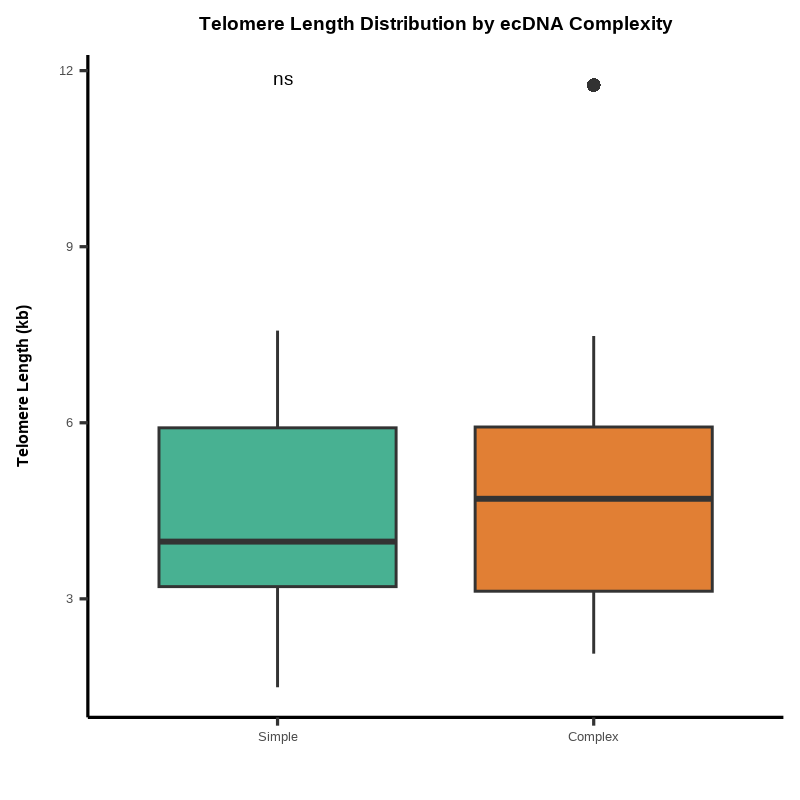

In [931]:
p_box <- ggplot(df_plot, aes(x = ecDNA_type, y = TL_kb, fill = ecDNA_type)) +
  geom_boxplot(outlier.shape = 16, outlier.size = 2, alpha = 0.8) +
  stat_compare_means(method = "wilcox.test", label = "p.signif", size = 5) +
  scale_fill_manual(values = c("Simple" = "#1b9e77", "Complex" = "#d95f02")) +
  labs(
    x = "",
    y = "Telomere Length (kb)",
    title = "Telomere Length Distribution by ecDNA Complexity"
  ) +
  theme_classic(base_size = 12) +
  theme(
    legend.position = "none",
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.title.y = element_text(face = "bold")
  )
p_box